# Setup

In [1]:
# Imports

import polars as pl
import duckdb
import numpy as np
import os
import math
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib_venn import venn2, venn3
from matplotlib import cm
import seaborn as sns
from tqdm.notebook import tqdm  # needs `ipywidgets` package

colormap = sns.cm.rocket
tab20 = cm.tab20

This file needs the Braun et al. 2020 dataset [https://doi.org/10.1038/s41591-020-0839-y] mutations translated to Hg38 with liftOver! 

This file needs the SOPRANO predicted peptide dataset.


In [2]:
# Paths
project_dir = Path("/data/teamgdansk/mwaleron/carmen-analysis")

data_dir = project_dir.joinpath("data")
figures_dir = project_dir.joinpath("figures")
temp_dir = project_dir.joinpath("temp")

db_main_file = data_dir.joinpath("carmen-main.parquet")

figures_gen_dir = figures_dir.joinpath("script-generated")

figures_main_dir = figures_gen_dir.joinpath("main-panels")
figures_supp_dir = figures_gen_dir.joinpath("supplementary")

data_subs_dir = data_dir.joinpath("subsidiary-files")
data_pub_dir = data_dir.joinpath("to-be-published")

braun_dataset_mut = data_subs_dir.joinpath("Braun_mutations_hg38_with_epitope_contigs.tsv")

pogo_annotations_file = data_dir.joinpath("carmen-mapped-protein-annotations-pogo.parquet")
contig_scaffold_list_file = data_pub_dir.joinpath("scaff_all_expanded.tsv")
contig_peptide_list_file = data_pub_dir.joinpath("contig_unique_peptide_list.tsv")
contig_hotspot_score_file = data_subs_dir.joinpath("sorted_normalized_contig_score.parquet")

main_samples_file_3 = data_subs_dir.joinpath("emilia_umap_with_ids.parquet")

soprano_bed = data_pub_dir.joinpath("Common_IP_v2.bed")
soprano_top70_bed = data_pub_dir.joinpath("Common_IP_top70.bed")
soprano_top6_bed = data_pub_dir.joinpath("Common_IP_top6.bed")
soprano_A0201_bed = data_pub_dir.joinpath("Common_IP_HLA0201.bed")
soprano_all_70_just_their_pep = data_subs_dir.joinpath("allhlaBinders_exprmean1.IEDBpeps(1).bed")

All the file reads for this stage of analysis.

In [3]:
contig_scaffold_list = pl.read_csv(
    contig_scaffold_list_file,
    separator='\t')
emilia_umap_with_ids = pl.read_parquet(main_samples_file_3)
soprano_peptides = pl.read_csv(soprano_bed, separator="\t", has_header=False)
soprano_pred = pl.read_csv(soprano_all_70_just_their_pep, separator="\t", has_header=False)
contig_peptides = pl.read_csv(contig_peptide_list_file, separator="\t")
pep_main = pl.scan_parquet(db_main_file)
score = pl.scan_parquet(contig_hotspot_score_file)
score2 = pl.read_csv("contig_promiscuity_score_2_3_4.csv")
score3 = pl.read_csv("contig_promiscuity_score_5_10.csv")

In [3]:
pg = pl.read_parquet(pogo_annotations_file)

In [8]:
pg.group_by("Peptide").agg(["Chromosome", "Gene_start", "Gene_end"]).with_columns(pl.col("Chromosome").list.unique(), pl.col("Gene_start").list.unique(), pl.col("Gene_end").list.unique()).filter(pl.col("Gene_start").list.len() >1)

Peptide,Chromosome,Gene_start,Gene_end
str,list[str],list[i64],list[i64]
"""KVVDFGSATY""","[""2"", ""5""]","[178612479, 200856745]","[178612509, 200856775]"
"""DPIVINHVI""","[""7"", ""17""]","[63833910, 151240426]","[63833937, 151240453]"
"""YLNENPLRAL""","[""3"", ""11"", ""X""]","[77332861, 111196616, 196820543]","[77336109, 111216426, 196827201]"
"""HHTQLIFVF""","[""17"", ""11"", ""3""]","[669731, 31681891, 196319957]","[669758, 31681918, 196319984]"
"""KMDENQFVAV""","[""4"", ""5"", ""8""]","[5836046, 26647638, 147399213]","[5836076, 26647668, 147399243]"
…,…,…,…
"""GSLQPLPPR""","[""2"", ""7"", … ""19""]","[40073660, 49577218, … 189806466]","[40073687, 49577245, … 189806493]"
"""RSSPYPTDV""","[""10"", ""7""]","[44693854, 49745920]","[44693881, 49745947]"
"""MFETFNTPAM""","[""7"", ""2"", ""17""]","[5528686, 81511593, … 131263921]","[5528716, 81511623, … 131263951]"


In [3]:
test = pl.read_parquet("/data/teamgdansk/carmen-peptide-clusters-characteristics_with_promiscuity.parquet")

In [4]:
test

ID,Sample_name,Peptides,Binding_alleles,UMAP_x,UMAP_y,Label,Freq_AAFA_A,Freq_AFB_A,Freq_AINDI_A,Freq_AISC_A,Freq_ALANAM_A,Freq_AMIND_A,Freq_CARB_A,Freq_CARHIS_A,Freq_CARIBI_A,Freq_EURCAU_A,Freq_FILII_A,Freq_HAWI_A,Freq_JAPI_A,Freq_KORI_A,Freq_MENAFC_A,Freq_MSWHIS_A,Freq_NCHI_A,Freq_SCAHIS_A,Freq_SCAMB_A,Freq_SCSEAI_A,Freq_VIET_A,Freq_AAFA_B,Freq_AFB_B,Freq_AINDI_B,Freq_AISC_B,Freq_ALANAM_B,Freq_AMIND_B,Freq_CARB_B,Freq_CARHIS_B,Freq_CARIBI_B,…,Freq_CARB_ABC_any,Freq_CARHIS_ABC_any,Freq_CARIBI_ABC_any,Freq_EURCAU_ABC_any,Freq_FILII_ABC_any,Freq_HAWI_ABC_any,Freq_JAPI_ABC_any,Freq_KORI_ABC_any,Freq_MENAFC_ABC_any,Freq_MSWHIS_ABC_any,Freq_NCHI_ABC_any,Freq_SCAHIS_ABC_any,Freq_SCAMB_ABC_any,Freq_SCSEAI_ABC_any,Freq_VIET_ABC_any,Freq_AAFA_ABC_all,Freq_AFB_ABC_all,Freq_AINDI_ABC_all,Freq_AISC_ABC_all,Freq_ALANAM_ABC_all,Freq_AMIND_ABC_all,Freq_CARB_ABC_all,Freq_CARHIS_ABC_all,Freq_CARIBI_ABC_all,Freq_EURCAU_ABC_all,Freq_FILII_ABC_all,Freq_HAWI_ABC_all,Freq_JAPI_ABC_all,Freq_KORI_ABC_all,Freq_MENAFC_ABC_all,Freq_MSWHIS_ABC_all,Freq_NCHI_ABC_all,Freq_SCAHIS_ABC_all,Freq_SCAMB_ABC_all,Freq_SCSEAI_ABC_all,Freq_VIET_ABC_all,Promiscuity
str,str,str,str,f64,f64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""P_1""","""sample_05H143""","""AAAELAAQK;AAALPAAALW;AAFDQRMKT…","""A*02:01;A*34:02;B*08:01;B*57:0…",-3.154053,7.0074296,2,0.156997,0.145948,0.049222,0.268294,0.194414,0.279521,0.146324,0.176801,0.154138,0.276425,0.068218,0.120805,0.147994,0.185754,0.198492,0.225582,0.094646,0.214107,0.165513,0.057917,0.03497,0.044721,0.037756,0.104219,0.108505,0.087936,0.109063,0.035275,0.056685,0.054778,…,0.319588,0.362861,0.351568,0.484377,0.103205,0.189181,0.162613,0.273946,0.412167,0.352757,0.150721,0.352402,0.344302,0.274646,0.112,0.004382,0.003414,0.001291,0.015343,0.01329,0.014858,0.003175,0.009396,0.007191,0.021055,0.000945,0.004881,0.000887,0.000531,0.009793,0.007345,0.00022,0.006683,0.004706,0.00094,0.000232,761.467231
"""P_2""","""sample_05H143""","""AAAKPTPPK;AIYEPKTFK;APATPLVNK;…","""A*02:01;A*34:02;B*08:01;B*57:0…",4.243943,-0.07093,1,0.156997,0.145948,0.049222,0.268294,0.194414,0.279521,0.146324,0.176801,0.154138,0.276425,0.068218,0.120805,0.147994,0.185754,0.198492,0.225582,0.094646,0.214107,0.165513,0.057917,0.03497,0.044721,0.037756,0.104219,0.108505,0.087936,0.109063,0.035275,0.056685,0.054778,…,0.319588,0.362861,0.351568,0.484377,0.103205,0.189181,0.162613,0.273946,0.412167,0.352757,0.150721,0.352402,0.344302,0.274646,0.112,0.004382,0.003414,0.001291,0.015343,0.01329,0.014858,0.003175,0.009396,0.007191,0.021055,0.000945,0.004881,0.000887,0.000531,0.009793,0.007345,0.00022,0.006683,0.004706,0.00094,0.000232,617.728358
"""P_3""","""sample_05H143""","""AAFPAEKESEW;AIKQLDYEW;AILKKVIQ…","""A*02:01;A*34:02;B*08:01;B*57:0…",-1.851911,0.8354455,4,0.156997,0.145948,0.049222,0.268294,0.194414,0.279521,0.146324,0.176801,0.154138,0.276425,0.068218,0.120805,0.147994,0.185754,0.198492,0.225582,0.094646,0.214107,0.165513,0.057917,0.03497,0.044721,0.037756,0.104219,0.108505,0.087936,0.109063,0.035275,0.056685,0.054778,…,0.319588,0.362861,0.351568,0.484377,0.103205,0.189181,0.162613,0.273946,0.412167,0.352757,0.150721,0.352402,0.344302,0.274646,0.112,0.004382,0.003414,0.001291,0.015343,0.01329,0.014858,0.003175,0.009396,0.007191,0.021055,0.000945,0.004881,0.000887,0.000531,0.009793,0.007345,0.00022,0.006683,0.004706,0.00094,0.000232,1697.995874
"""P_4""","""sample_05H143_1""","""AAAKPTPPK;APATPLVNK;ATALPTGTSK…","""A*02:01;A*34:02;B*08:01;B*57:0…",4.2816453,-0.099384,1,0.156997,0.145948,0.049222,0.268294,0.194414,0.279521,0.146324,0.176801,0.154138,0.276425,0.068218,0.120805,0.147994,0.185754,0.198492,0.225582,0.094646,0.214107,0.165513,0.057917,0.03497,0.044721,0.037756,0.104219,0.108505,0.087936,0.109063,0.035275,0.056685,0.

In [15]:
hlas = pl.read_parquet("../data/carmen-hla-sequences.parquet")

In [17]:
hlas

Allele,Sequence,Pseudo_sequence
str,str,str
"""A*01:01""","""GSHSMRYFFTSVSRPGRGEPRFIAVGYVDD…","""YFAMYQENMAHTDANTLYIIYRDYTWVARV…"
"""A*01:02""","""GSHSMRYFSTSVSRPGSGEPRFIAVGYVDD…","""YSAMYQENMAHTDANTLYIIYRDYTWVARV…"
"""A*01:03""","""GSHSMRYFFTSVSRPGRGEPRFIAVGYVDD…","""YFAMYQENMAHTDANTLYIMYRDYTWVARV…"
"""A*01:06""","""GSHSMRYFFTSVSRPGRGEPRFIAVGYVDD…","""YFAMYQENMAHTDANTLYIIYRDYTWVALA…"
"""A*01:07""","""GSHSMRYFFTSVSRPGRGEPRFIAVGYVDD…","""YFAMYQENVAHTDENTLYIIYRDYTWVARV…"
…,…,…
"""C*18:08""","""GSHSMRYFDTAVSRPGRGEPRFISVGYVDD…","""YDSGYREKYRQADVNKLYLRFNFYTWAERA…"
"""C*18:09""","""GSHSMRYFYTAVSRPGRGEPRFISVGYVDD…","""YYSGYREKYRQADVNKLYLRFNFYTWAERA…"
"""C*18:10""","""CSHSMRYFDTAVSRPGRGEPRFISVGYVDD…","""YDSGYREKYRQADVNKLYLRFNFYTWAERA…"


In [14]:
pep_main.group_by("Haplotype").len().collect()

Haplotype,len
str,u32
"""A*03:01:01,B*35:01,C*04:01:01""",14216
"""A*02:52""",2
"""A*03:01,A*24:02,B*18:01,B*27:0…",2199
"""A*11:01,A*68:01,B*15:01,B*35:0…",20297
"""A*11:01,A*32:01,B*18:01,B*44:0…",8349
…,…
"""A*02:01,B*15:11,C*03:03""",77117
"""C*07:02""",5518
"""A*03:01,B*15:01,B*35:01,B*44:0…",19


In [18]:
pep_main.fetch(5)

Study_id,Sample_name,Peptide,Peptide_type,Spectral_count,Assigned_modifications,Haplotype,Netmhcpan_binder,Promiscuity
str,str,str,str,i64,str,str,str,f64
"""MSV000080527-84172-84442""","""sample_A0101""","""AADIFYSRY""","""canonical""",12,null,"""A*01:01""","""Y""",0.688129
"""MSV000080527-84172-84442""","""sample_A0101""","""AADLNLVLY""","""canonical""",14,null,"""A*01:01""","""Y""",8.672632
"""MSV000080527-84172-84442""","""sample_A0101""","""AADPNAAWAAY""","""canonical""",1,null,"""A*01:01""","""Y""",0.387766
"""MSV000080527-84172-84442""","""sample_A0101""","""AADPNAAWAAYY""","""canonical""",7,null,"""A*01:01""","""Y""",0.769507
"""MSV000080527-84172-84442""","""sample_A0101""","""AAEDIINYTEPKLGY""","""canonical""",1,null,"""A*01:01""","""Y""",0.0


In [11]:
pep_main.group_by("Sample_name").len().collect().sort("Sample_name")

Sample_name,len
str,u32
"""sample_05H143""",5034
"""sample_05H143_1""",4915
"""sample_05H143_2""",4876
"""sample_05H143_3""",5034
"""sample_05H143_4""",5034
…,…
"""sample_trachea_W6_005""",2844
"""sample_trachea_W6_006""",3530
"""sample_trachea_W6_007""",1988


In [9]:
contig_scaffold_list.filter(pl.col("gap_width")==0).with_columns(len = pl.col("Gene_end")-pl.col("Gene_start")).mean()

Id,Chromosome,Gene_start,Gene_end,Contigs,Multi_contig,gap_width,len
str,str,f64,f64,str,str,f64,f64
null,null,7.5583e7,7.5584e7,null,null,0.0,1176.75401


# Soprano comparison

How many peptides constitute the predicted immunopeptidome of top 70 HLA haplotypes used in Soprano analysis?

In [4]:
predicted_9mer_immunopeptidome = soprano_pred.select(pl.col("column_4").str.split(",").explode().unique().len()).item()

In [5]:
soprano_pred.select(pl.col("column_4").str.split(",").explode().unique().str.len_chars())

column_4
u32
9
9
9
9
9
…
9
9
9


Because Soprano only predicts 9mers lets compare that with out 9mer count:

In [5]:
pep_main_9m = pep_main.filter(pl.col("Peptide").str.len_chars()==9)

In [7]:
carmen_9mer_count = pep_main_9m.select(pl.col("Peptide").unique().len()).collect().item()

In [8]:
overlap_between_carmen_and_predicted_9mer = soprano_pred.select(pl.col("column_4").str.split(",").explode().unique()).lazy().join(pep_main_9m.select(pl.col("Peptide").unique()), left_on="column_4", right_on="Peptide").select(pl.len()).collect().item()

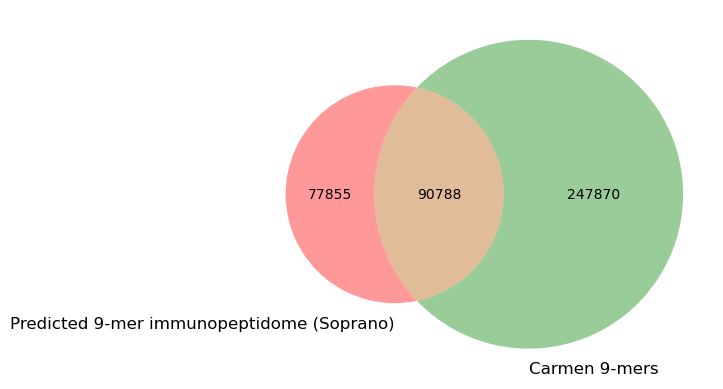

In [10]:
venn2(subsets = (predicted_9mer_immunopeptidome - overlap_between_carmen_and_predicted_9mer, carmen_9mer_count - overlap_between_carmen_and_predicted_9mer, overlap_between_carmen_and_predicted_9mer), set_labels=("Predicted 9-mer immunopeptidome (Soprano)", "Carmen 9-mers"))
plt.savefig("Carmen_Soprano_overlap_venn.pdf")

In [4]:
soprano_top70 = pl.read_csv(soprano_top70_bed, separator="\t", has_header=False)
soprano_top70 = soprano_top70.with_columns(pl.col("column_5").str.split(",").list.unique()).with_columns(npep = pl.col("column_5").list.len())
top70_overlap_peptides = soprano_top70.select("column_5").explode("column_5").unique()


In [5]:
soprano_top70 = pl.read_csv(soprano_top70_bed, separator="\t", has_header=False)


In [6]:
soprano_top70.with_columns(pl.col("column_5").str.split(",").list.unique()).explode("column_5").unique("column_5")

column_1,column_2,column_3,column_4,column_5,column_6
str,i64,i64,str,str,str
"""chr3""",36858027,36858049,"""C45435""","""AALHIFLEI""","""HLA-A0201,HLA-B4001,HLA-B4402,…"
"""chr19""",41276194,41276298,"""C219205""","""ASYGVRRGR""","""HLA-A030101,HLA-A680101,HLA-B2…"
"""chr19""",8474193,8474244,"""C211748""","""GLDHMASSIERM""","""HLA-A0201,HLA-B4001,HLA-B4402,…"
"""chr15""",96337410,96337535,"""C179546""","""LEEYVRSQY""","""HLA-A2402,HLA-A2410,HLA-B1802,…"
"""chr6""",43051400,43051468,"""C83972""","""RYLHVTSLL""","""HLA-A030101,HLA-A680101,HLA-B2…"
…,…,…,…,…,…
"""chr9""",136459167,136459211,"""C120998""","""TEAYEYAQSL""","""HLA-A2501,HLA-A2601,HLA-B3507,…"
"""chr19""",6476911,6476967,"""C211081""","""NLTELVVAV""","""HLA-A0201,HLA-B0702,HLA-B1801,…"
"""chr7""",2360769,2360902,"""C91969""","""IVVDNVPQV""","""HLA-A0301,HLA-A2902,HLA-B0801,…"


In [10]:
soprano_peptides.with_columns(pl.col("column_5").str.split(",").list.unique()).explode("column_5").unique("column_5")

column_1,column_2,column_3,column_4,column_5
str,i64,i64,str,str
"""chr9""",120833312,120833456,"""C118023""","""HPDDSVKILTL"""
"""chr15""",90473929,90473967,"""C179155""","""DHINDIIKI"""
"""chr3""",196899924,196899957,"""C57439""","""DVFNEDFSNR"""
"""chr1""",23694660,23694791,"""C3924""","""HIDLGIKYDPSIGIY"""
"""chr20""",53966915,53966956,"""C230114""","""KPRTSLMAF"""
…,…,…,…,…
"""chr1""",155312255,155312395,"""C15875""","""DIMDSSLTR"""
"""chr12""",110492017,110492091,"""C155150""","""IQASTVVTY"""
"""chr2""",197498675,197498824,"""C39158""","""LADAVAVTM"""


In [11]:
top70_overlap_peptides

column_5
str
"""QEAEAWLNY"""
"""SPNKHNRLY"""
"""TRELPSFL"""
"""KTLEGHDGIVL"""
"""SSYGNIRAV"""
…
"""TEGISTSDIITR"""
"""HSMRQAELAQW"""
"""LENIFLPLF"""


In [12]:
top70_overlap_peptides.filter(pl.col("column_5").str.len_chars()==9)

column_5
str
"""QEAEAWLNY"""
"""SPNKHNRLY"""
"""SSYGNIRAV"""
"""YSRYQTLEL"""
"""EVIDVVRTM"""
…
"""VRFLLGLRF"""
"""ASNIANTTY"""
"""FLLKLTPLL"""


In [13]:
top70_overlap_peptides.lazy().filter(pl.col("column_5").str.len_chars()==9).join(pep_main_9m.select(pl.col("Peptide").unique()), left_on="column_5", right_on="Peptide").collect()

column_5
str
"""AEVAAEKSF"""
"""RGRGKSAAL"""
"""ALQNLIPSL"""
"""REEHQGENL"""
"""KQYLQRQER"""
…
"""EEIPRQLQY"""
"""YLVYHPVQL"""
"""QHEGQHYNI"""


# t70 analysis

In [8]:
bigscore = score.join(contig_scaffold_list.lazy(), on="Id").collect().join(score2, on="Id").join(score3, on="Id")

In [9]:
soprano_top70 = pl.read_csv(soprano_top70_bed, separator="\t", has_header=False)
soprano_top70 = soprano_top70.with_columns(pl.col("column_5").str.split(",").list.unique()).with_columns(npep = pl.col("column_5").list.len())
top70_overlap_peptides = soprano_top70.select("column_5").explode("column_5").unique()
top70_all_possible_peptides = soprano_top70.join(contig_peptides, left_on="column_4", right_on="contig").with_columns(pl.col("pep_list").str.split(",").list.unique()).select("pep_list").explode("pep_list").unique()
top70_carmen_only = top70_all_possible_peptides.join(top70_overlap_peptides, left_on="pep_list", right_on="column_5", how="anti")
t70carmensop_scores = top70_overlap_peptides.lazy().join(pep_main.unique("Peptide"), left_on="column_5", right_on="Peptide", how="left", coalesce=True).collect()
t70carmen_scores = top70_carmen_only.lazy().join(pep_main, left_on="pep_list", right_on="Peptide").collect()

In [17]:
pep_main.filter(pl.col("Promiscuity")>13).select("Peptide").unique("Peptide").filter(~pl.col("Peptide").is_in(t70carmensop_scores.filter(pl.col("Promiscuity")>13).select("column_5")["column_5"])).collect()

Peptide
str
"""LPLEKVYSL"""
"""RQWLAIQKL"""
"""ALSPINIQL"""
"""SPIQKPQGL"""
"""SLYQAMRQK"""
…
"""FPKSSSSSL"""
"""APREPFAHSL"""
"""TLDKHLRQK"""


In [15]:
t70carmensop_scores.filter(pl.col("Promiscuity")>13).select("column_5")

column_5
str
"""KVATEFESF"""
"""VRPPPGPEL"""
"""DRNKRFISI"""
"""ASEQQALHTVQY"""
"""RIKAIQLEY"""
…
"""SGYKIYPGHGRRY"""
"""RQLDMELVSV"""
"""ALRLPPTSL"""


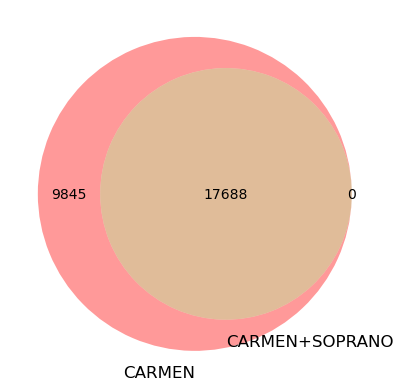

In [22]:
venn2((9845,0,17688),("CARMEN", "CARMEN+SOPRANO", ""))
plt.savefig("CARMEN_SOPRANO_VENN_ONLY_PROMISCUOUS_PEPTIDES.pdf")

In [13]:
percent_remaining = []
oglen = pep_main.select(pl.col("Peptide").unique()).select(pl.len()).collect().item()
for threshold in range(1,214):
    peptidesrm = pep_main.filter(pl.col("Promiscuity")>threshold).select(pl.col("Peptide").unique()).select(pl.len()).collect().item()
    percent_remaining.append(peptidesrm/oglen)

In [14]:
percent_overlap = []
for threshold in range(1,214):
    peptidesig = pep_main.filter(pl.col("Promiscuity")>threshold).select(pl.col("Peptide").unique()).select(pl.len()).collect().item()
    peptidesol = top70_overlap_peptides.lazy().join(pep_main.filter(pl.col("Promiscuity")>threshold).select(pl.col("Peptide").unique()), right_on="Peptide", left_on="column_5").select(pl.len()).collect().item()
    percent_overlap.append(peptidesol/peptidesig)

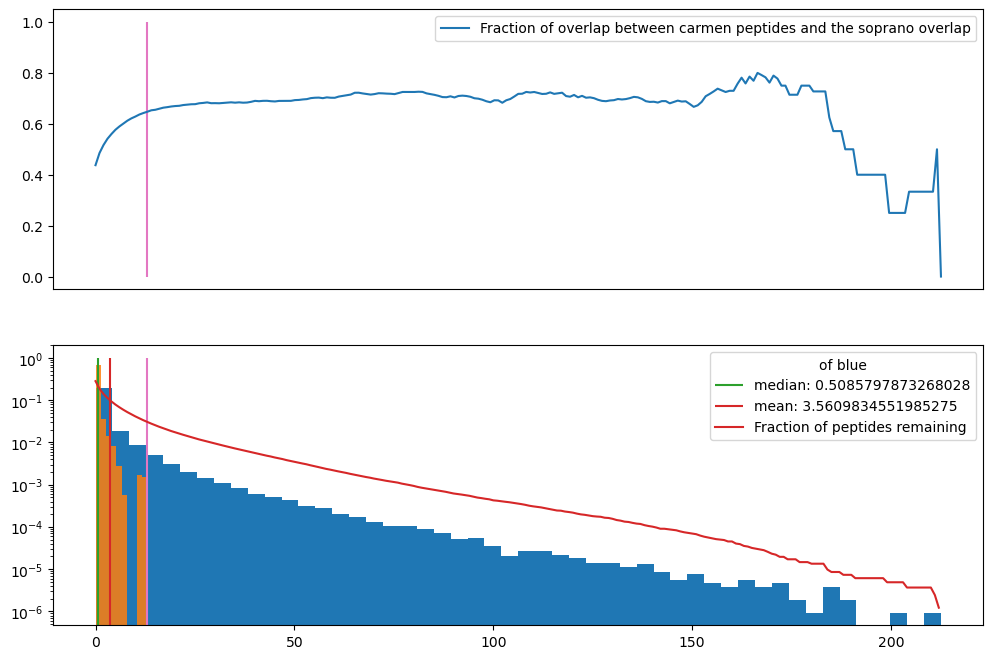

In [15]:

fig = plt.figure(figsize=(12,8))
ax1 = plt.subplot(211)
ax1.vlines(13,0,1,color="tab:pink")
ax1.plot(percent_overlap, label="Fraction of overlap between carmen peptides and the soprano overlap")
ax1.legend()
ax1.set_xticklabels([])
ax1.set_xticks([])
ax = plt.subplot(212)
ax.hist(t70carmensop_scores["Promiscuity"], density=True, bins=50)
ax.vlines(t70carmensop_scores["Promiscuity"].median(), 0, 1, color="tab:green", label=f"median: {t70carmensop_scores['Promiscuity'].median()}")
ax.vlines(t70carmensop_scores["Promiscuity"].mean(), 0, 1, color="tab:red", label=f"mean: {t70carmensop_scores['Promiscuity'].mean()}")
ax.vlines(13,0,1,color="tab:pink")
ax.hist(t70carmen_scores["Promiscuity"], density=True, color="tab:orange", alpha=0.85)
ax.plot(percent_remaining, color="tab:red", label="Fraction of peptides remaining")
ax.legend(title="of blue")
ax.set_yscale("log")
fig.savefig("Carmen_comparison_of_predicted_vs_detected_peptides_promiscuity_top70HLAs.pdf")

In [19]:
contig_peptides.with_columns(pl.col("pep_list").str.split(",").list.unique()).explode("pep_list")

contig,pep_list,unique_peptides
str,str,i64
"""C1""","""SQELQTFLF""",1
"""C10""","""ELLRKQNL""",1
"""C100""","""ARGPSGLLL""",2
"""C100""","""LARGPSGLLL""",2
"""C1000""","""SPSHVVQFR""",1
…,…,…
"""C99997""","""AHGETLITY""",2
"""C99997""","""SPAHGETL""",2
"""C99998""","""YLIERLNETL""",2


In [20]:
contig_peptides.with_columns(pl.col("pep_list").str.split(",").list.unique()).explode("pep_list").filter(pl.col("pep_list").str.len_chars()==9)

contig,pep_list,unique_peptides
str,str,i64
"""C1""","""SQELQTFLF""",1
"""C100""","""ARGPSGLLL""",2
"""C1000""","""SPSHVVQFR""",1
"""C10000""","""ETIKSISQQ""",8
"""C10000""","""LQRNPPPNA""",8
…,…,…
"""C99993""","""FTEDKNIEK""",1
"""C99995""","""PFDVVTVTI""",2
"""C99996""","""LYEQAGPSF""",2


In [32]:
top70_overlap_peptides.lazy().join(pep_main, left_on="column_5", right_on="Peptide").group_by("Sample_name").agg().collect()

Sample_name
str
"""sample_PXD014397_F120190129_PF…"
"""sample_VY20210319_HT_CPTAC5_Cl…"
"""sample_C1R-G0101"""
"""sample_MV4_MHC1"""
"""sample_PXD025716_AML_07_Rep_4"""
…
"""sample_PXD027182_NB8_PASEGA_0B…"
"""sample_SupB15RT-3"""
"""sample_PXD025345_191222_SB7"""


In [34]:
top70_all_possible_peptides.lazy().join(pep_main, left_on="pep_list", right_on="Peptide").group_by("Sample_name").agg().collect()

Sample_name
str
"""sample_PXD025716_AML_12_Rep_4"""
"""sample_10H080"""
"""sample_A2902"""
"""sample_HFX0068_JPT_library_mix…"
"""sample_B5201"""
…
"""sample_20200131_Lum2_IO_U3000_…"
"""sample_SupB15RT-2"""
"""sample_PXD025716_AML_13_Rep_1"""


In [33]:
top70_carmen_only.lazy().join(pep_main, left_on="pep_list", right_on="Peptide").group_by("Sample_name").agg().collect()

Sample_name
str
"""sample_20210429_ECL2_OBJ41515_…"
"""sample_Mel-39_HLA-I"""
"""sample_20200729_ECL1_OBJ41041_…"
"""sample_RCC990_Benign"""
"""sample_20210426_Lum2_IO_U3000_…"
…
"""sample_RCC224_Tumor"""
"""sample_20200729_ECL1_OBJ41041_…"
"""sample_20200731_COL011_00040_H…"


# t70 9-mer

In [16]:
soprano_top70 = pl.read_csv(soprano_top70_bed, separator="\t", has_header=False)
soprano_top70 = soprano_top70.with_columns(pl.col("column_5").str.split(",").list.unique()).with_columns(npep = pl.col("column_5").list.len())
top70_overlap_peptides_9m = soprano_top70.select("column_5").explode("column_5").unique().filter(pl.col("column_5").str.len_chars()==9)
top70_all_possible_peptides_9m = soprano_top70.join(contig_peptides, left_on="column_4", right_on="contig").with_columns(pl.col("pep_list").str.split(",").list.unique()).select("pep_list").explode("pep_list").unique().filter(pl.col("pep_list").str.len_chars()==9)
top70_carmen_only_9m = top70_all_possible_peptides_9m.join(top70_overlap_peptides_9m, left_on="pep_list", right_on="column_5", how="anti")
t70carmensop_scores_9m = top70_overlap_peptides_9m.lazy().join(pep_main.unique("Peptide"), left_on="column_5", right_on="Peptide", how="left", coalesce=True).collect()
t70carmen_scores_9m = top70_carmen_only_9m.lazy().join(pep_main, left_on="pep_list", right_on="Peptide").collect()

In [30]:
250293-132165

118128

In [22]:
132165-5641

126524

In [17]:
top70_overlap_peptides_9m.lazy().join(pep_main, left_on="column_5", right_on="Peptide").group_by("Sample_name").agg().collect()

Sample_name
str
"""sample_3112_ML_TC1913_1e8_100m…"
"""sample_20210413_ECL2_OBJ41515_…"
"""sample_PXD027182_NB2_PANXJL_0B…"
"""sample_PXD025716_AML_04_Rep_3"""
"""sample_Donor_5_expanded_MHC1"""
…
"""sample_210512_JB_SMMC_p1431_24…"
"""sample_F1202000304_PF_MDAMB231…"
"""sample_14H124_4"""


In [35]:
top70_all_possible_peptides_9m.lazy().join(pep_main, left_on="pep_list", right_on="Peptide").group_by("Sample_name").agg().collect()

Sample_name
str
"""sample_CM467_HLA-Ip_BR1"""
"""sample_F20180830_KP_THP1_BB72_…"
"""sample_myelon_W6_001"""
"""sample_PXD025716_CLL_06_Rep_2"""
"""sample_PXD027182_NB4_PAPCTS_0B…"
…
"""sample_PXD025345_Sydney_AQ6_al…"
"""sample_bladder_W6_001"""
"""sample_PXD014397_LM44_wIFN_W63…"


In [36]:
top70_carmen_only_9m.lazy().join(pep_main, left_on="pep_list", right_on="Peptide").group_by("Sample_name").agg().collect()

Sample_name
str
"""sample_FL002_HLA-I"""
"""sample_20200124_Lum2_IO_U3000_…"
"""sample_FL003_HLA-I"""
"""sample_PXD033935_170121_AM_ATR…"
"""sample_DC3W6_R1"""
…
"""sample_PXD033935_170116_AM_ATR…"
"""sample_Mel-24_HLA-I"""
"""sample_Human_L128_1E8_MHC1"""


In [18]:
percent_remaining_9m = []
oglen = pep_main_9m.select(pl.col("Peptide").unique()).select(pl.len()).collect().item()
for threshold in range(1,214):
    peptidesrm = pep_main_9m.filter(pl.col("Promiscuity")>threshold).select(pl.col("Peptide").unique()).select(pl.len()).collect().item()
    percent_remaining_9m.append(peptidesrm/oglen)

In [19]:
percent_overlap_9m = []
for threshold in range(1,214):
    peptidesig = pep_main_9m.filter(pl.col("Promiscuity")>threshold).select(pl.col("Peptide").unique()).select(pl.len()).collect().item()
    peptidesol = top70_overlap_peptides.lazy().join(pep_main_9m.filter(pl.col("Promiscuity")>threshold).select(pl.col("Peptide").unique()), right_on="Peptide", left_on="column_5").select(pl.len()).collect().item()
    percent_overlap_9m.append(peptidesol/peptidesig)

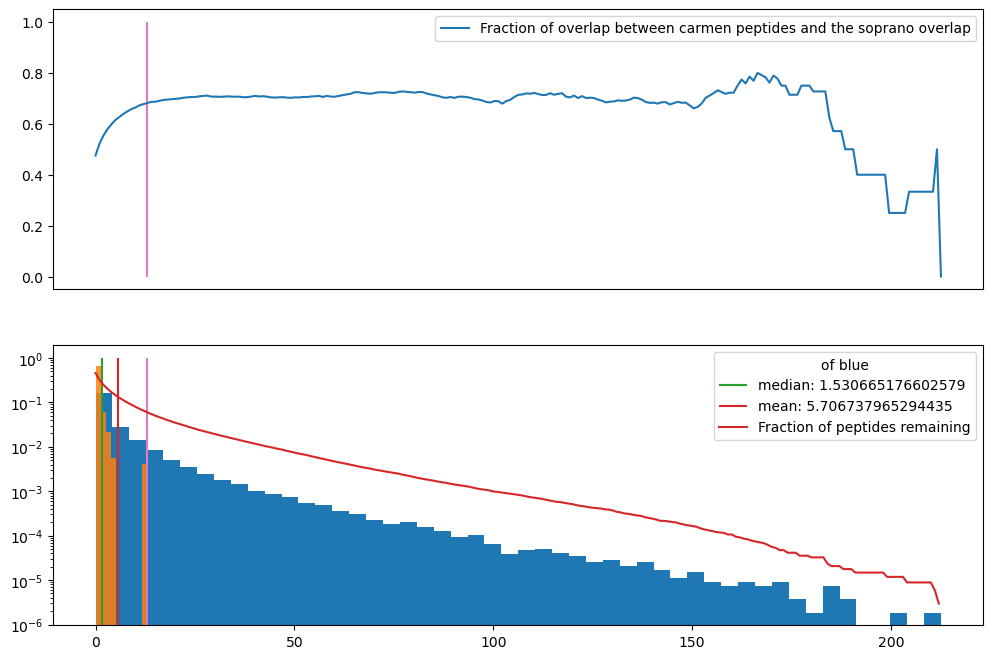

In [20]:
fig = plt.figure(figsize=(12,8))
ax1 = plt.subplot(211)
ax1.vlines(13,0,1,color="tab:pink")
ax1.plot(percent_overlap_9m, label="Fraction of overlap between carmen peptides and the soprano overlap")
ax1.legend()
ax1.set_xticklabels([])
ax1.set_xticks([])
ax = plt.subplot(212)
ax.hist(t70carmensop_scores_9m["Promiscuity"], density=True, bins=50)
ax.vlines(t70carmensop_scores_9m["Promiscuity"].median(), 0, 1, color="tab:green", label=f"median: {t70carmensop_scores_9m['Promiscuity'].median()}")
ax.vlines(t70carmensop_scores_9m["Promiscuity"].mean(), 0, 1, color="tab:red", label=f"mean: {t70carmensop_scores_9m['Promiscuity'].mean()}")
ax.vlines(13,0,1,color="tab:pink")
ax.hist(t70carmen_scores_9m["Promiscuity"], density=True, color="tab:orange", alpha=0.85)
ax.plot(percent_remaining_9m, color="tab:red", label="Fraction of peptides remaining")
ax.legend(title="of blue")
ax.set_yscale("log")
fig.savefig("Carmen_comparison_of_predicted_vs_detected_peptides_promiscuity_top70HLAs_9mers_only.pdf")

In [33]:
soprano_top70.join(bigscore, left_on="column_4", right_on="Contigs")

column_1,column_2,column_3,column_4,column_5,column_6,npep,unique_pep_idx,mut_count_idx,pop_cov_idx,Id,pop_cov,vlen,popcov_but_sqrt,unique_peptides,mutation_count,exon_length,normalized_unique_pep,ranking,Chromosome,Gene_start,Gene_end,Multi_contig,gap_width,popcov_but_sqrt2,popcov_but_sqrt3,popcov_but_sqrt4,popcov_but_sqrt_right,popcov_but_sqrt5,popcov_but_sqrt10,popcov_but_sqrt50,popcov_but_sqrt100
str,i64,i64,str,list[str],str,u32,u32,u32,u32,str,f64,f64,f64,u32,i64,i64,f64,u32,str,i64,i64,str,i64,f64,f64,f64,f64,f64,f64,i64,i64
"""chr11""",77629763,77629817,"""C140830""","[""EEESKEPVA"", ""EHLYVMVNA"", … ""LYVMVNAKF""]","""HLA-A020101,HLA-B390602,HLA-C0…",4,31791,10971,19347,"""S_0_140830""",8.530927,6.267674,22.998206,4,190,237,0.016878,62109,"""chr11""",77625796,77629817,"""N""",0,0.0,0.0,0.0,22.998206,0.0,0.0,0,0
"""chr10""",102379853,102379879,"""C128891""","[""KVLFPLLTK"", ""VLFPLLTKL"", ""KVLFPLLTKL""]","""HLA-A0301,HLA-A1101,HLA-A03,HL…",3,159204,226533,12310,"""S_0_128891""",12.324076,6.627347,34.036203,3,2,1402,0.00214,398047,"""chr10""",102379649,102379879,"""N""",0,2.825331,0.0,0.0,34.036203,0.0,0.0,0,0
"""chr6""",26385251,26385277,"""C80497""","[""SVALVIHNV""]","""HLA-A0205,HLA-A0206,HLA-A6802,…",1,165893,51343,27103,"""S_0_80497""",6.726483,5.09531,16.6068,1,48,544,0.001838,244339,"""chr6""",26385251,26385277,"""N""",0,0.0,0.0,0.0,16.6068,0.0,0.0,0,0
"""chr15""",100900643,100900702,"""C179744""","[""QVYSEFVRR"", ""FVRRSVEY"", … ""FVEEQVYSEF""]","""HLA-A0201,HLA-A1101,HLA-B3501,…",6,10121,144475,34263,"""S_0_179744""",7.527434,1.922643,12.868704,6,12,184,0.032609,188859,"""chr15""",100900643,100900702,"""N""",0,0.0,0.0,0.0,12.868704,0.0,0.0,0,0
"""chr1""",32222538,32222630,"""C5330""","[""VAKDPIVNVWY"", ""REGDLLFTVA"", … ""LLQGHERSI""]","""HLA-A0206,HLA-B3802,HLA-A0201,…",15,98242,73037,14112,"""S_0_5330""",13.339478,4.172616,30.33849,18,33,2998,0.006004,185391,"""chr1""",32222538,32224105,"""N""",0,4.081448,0.0,0.0,30.33849,0.0,0.0,0,0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""chr7""",123542173,123542220,"""C100146""","[""VILQAEHELNL"", ""AEHELNLARKM"", … ""QAEHELNL""]","""HLA-A0101,HLA-B2705,HLA-B4403,…",5,216301,19100,73512,"""S_0_100146""",1.622634,6.395383,4.412665,5,120,10229,0.000489,308913,"""chr7""",123542173,123545622,"""N""",0,0.0,0.0,0.0,4.412665,0.0,0.0,0,0
"""chr5""",119114475,119114505,"""C73214""","[""KTASQVHLMKF"", ""KTASQVHLM"", … ""KTASQVHLMK""]","""HLA-A0220,HLA-A6801,HLA-B3503,…",4,16600,53888,26685,"""S_0_73214""",10.96191,1.371849,16.882229,5,46,198,0.025253,97173,"""chr5""",119110282,119114505,"""N""",0,1.175317,0.0,0.0,16.882229,0.0,0.0,0,0
"""chr9""",33886893,33886937,"""C113424""","[""YSPPTFRFL"", ""PYSPPTFRFL"", … ""YPYSPPTF""]","""HLA-A2407,HLA-A0201,HLA-A2402,…",5,1273,218918,10770,"""S_0_113424""",26.845094,0.97429,37.719889,6,3,86,0.069767,230961,"""chr9""",33886893,33886937,"""N""",0,0.0,0.0,0.0,37.719889,0.0,0.0,0,0


In [34]:
soprano_top70.join(bigscore, left_on="column_4", right_on="Contigs")["popcov_but_sqrt"].mean()

39.202572198455655

In [35]:
soprano_top70.join(bigscore, left_on="column_4", right_on="Contigs")["popcov_but_sqrt"].median()

13.402532962319883

In [30]:
bigscore.filter(~pl.col("Contigs").is_in(soprano_top70["column_4"]), pl.col("popcov_but_sqrt")>0)["popcov_but_sqrt"].mean()

5.839856966313859

# contigs t70

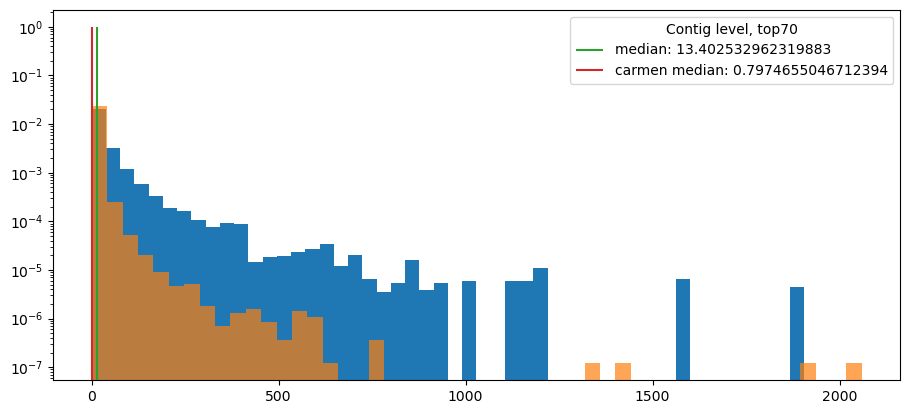

In [9]:
mm=1/25.4
fig = plt.figure(figsize=(3*92.538*mm,3*40.72*mm))
ax = plt.subplot(111)
ax.hist(soprano_top70.join(bigscore, left_on="column_4", right_on="Contigs")["popcov_but_sqrt"], density=True, bins=50)
ax.hist(bigscore.filter(~pl.col("Contigs").is_in(soprano_top70["column_4"]))["popcov_but_sqrt"], density=True, color="tab:orange", alpha=0.7, bins=50)
ax.vlines(soprano_top70.join(bigscore, left_on="column_4", right_on="Contigs")["popcov_but_sqrt"].median(), 0, 1, color="tab:green", label=f'median: {soprano_top70.join(bigscore, left_on="column_4", right_on="Contigs")["popcov_but_sqrt"].median()}')
ax.vlines(bigscore.filter(~pl.col("Contigs").is_in(soprano_top70["column_4"]))["popcov_but_sqrt"].median(), 0, 1, color="tab:red", label=f'carmen median: {bigscore.filter(~pl.col("Contigs").is_in(soprano_top70["column_4"]))["popcov_but_sqrt"].median()}')
ax.set_yscale("log")
ax.legend(title="Contig level, top70")
fig.savefig("Carmen_comparison_of_predicted_vs_detected_contigs_promiscuity_top70HLAs.pdf")

In [23]:
pep_main.filter(pl.col("Promiscuity")>13.068715).select("Sample_name").unique().collect()

Sample_name
str
"""sample_PXD025716_AML_02_Rep_5"""
"""sample_20220722_ECL2_IO_OBJ415…"
"""sample_MEL_13240-006_IFN"""
"""sample_SupB15RT-2"""
"""sample_brain_W6_012"""
…
"""sample_PXD146-untreated2-HLA-I"""
"""sample_2065_L_MdB073_7mei19_do…"
"""sample_PBMC004"""


(array([3.71369433e-02, 7.77082659e-03, 2.75873401e-03, 1.01799640e-03,
        4.29297413e-04, 2.13743016e-04, 1.12305652e-04, 5.79642076e-05,
        1.81138149e-05, 9.05690744e-06]),
 array([ 13.06927557,  33.26110551,  53.45293545,  73.64476539,
         93.83659533, 114.02842527, 134.22025521, 154.41208515,
        174.60391509, 194.79574504, 214.98757498]),
 <BarContainer object of 10 artists>)

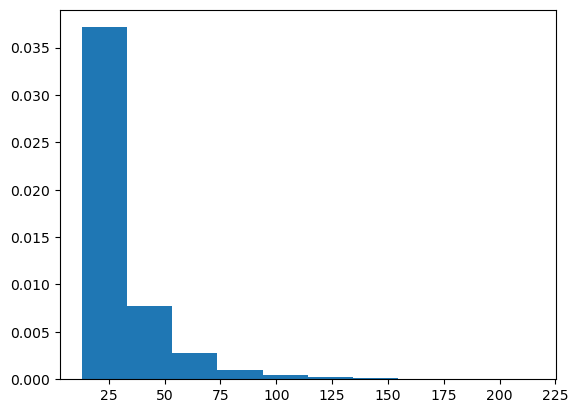

In [24]:
plt.hist(pep_main.filter(pl.col("Promiscuity")>13.068715).unique("Peptide").collect()["Promiscuity"], density=True)

In [25]:
pep_main.filter(pl.col("Promiscuity")>13.068715).unique("Peptide").collect()

Study_id,Sample_name,Peptide,Peptide_type,Spectral_count,Assigned_modifications,Haplotype,Netmhcpan_binder,Promiscuity
str,str,str,str,i64,str,str,str,f64
"""MSV000080527-84172-84442""","""sample_A0201""","""RMFPGEVAL""","""canonical""",6,null,"""A*02:01""","""Y""",14.558614
"""MSV000080527-84172-84442""","""sample_A0203""","""GLISGILRV""","""canonical""",7,null,"""A*02:03""","""Y""",35.152312
"""MSV000090323""","""sample_20200124_Lum2_IO_U3000_…","""AVLQSPGLSGK""","""canonical""",1,null,null,null,14.887386
"""MSV000080527-84172-84442""","""sample_B1501""","""AQRQEIRTAY""","""canonical""",22,null,"""B*15:01""","""Y""",35.040356
"""MSV000080527-84172-84442""","""sample_A1101""","""KVIDRILYK""","""canonical""",3,null,"""A*11:01""","""Y""",34.788142
…,…,…,…,…,…,…,…,…
"""MSV000080527-84172-84442""","""sample_B4402""","""EEAEWQTRW""","""canonical""",19,null,"""B*44:02""","""Y""",51.552929
"""MSV000080527-84172-84442""","""sample_A3002""","""GQKINIHEY""","""canonical""",8,null,"""A*30:02""","""Y""",39.111587
"""MSV000080527-84172-84442""","""sample_A0203""","""RLKSIIQEV""","""canonical""",5,null,"""A*02:03""","""Y""",16.270005


In [26]:
pep_main.select(pl.col("Peptide").unique()).select(pl.len()).collect()

len
u32
816222


This part uses the class I MHC ligand data from iedb, you can find the current version of the database here https://www.iedb.org/database_export_v3.php i don't know what version this file was generated from, it's not in the article anyway but leaving this here in case someone is curious.

In [ ]:
%%script false --no-raise-error
iedb_pep = pl.scan_csv(data_subs_dir.joinpath("MHC_I_combined.tsv"), separator="\t").select(pl.col("peptide").unique())
iedb_prom = iedb_pep.join(pep_main.select("Peptide", "Promiscuity").unique("Peptide"), right_on="Peptide", left_on="peptide", how="left").collect().fill_null(0)
iedb_pep.select(pl.col("peptide").unique()).collect()
iedb_peptide_count = iedb_pep.select(pl.col("peptide").unique()).select(pl.len()).collect().item()
peptides_unique_to_iedb = iedb_pep.lazy().join(pep_main.select("Peptide", "Promiscuity").unique("Peptide"), left_on="peptide", right_on="Peptide", how="anti").select(pl.len()).collect().item()
pep_main.select("Peptide", "Promiscuity").unique("Peptide").join(iedb_pep, left_on="Peptide", right_on="peptide").collect()
peptides_common_with_iedb = pep_main.select("Peptide", "Promiscuity").unique("Peptide").join(iedb_pep, left_on="Peptide", right_on="peptide").select(pl.len()).collect().item()
pep_main.select("Peptide", "Promiscuity").unique("Peptide").join(iedb_pep, left_on="Peptide", right_on="peptide", how="anti").collect()
unique_to_carmen = pep_main.select("Peptide", "Promiscuity").unique("Peptide").join(iedb_pep, left_on="Peptide", right_on="peptide", how="anti").select(pl.len()).collect().item()
venn2((peptides_unique_to_iedb, unique_to_carmen, peptides_common_with_iedb),("IEDB peptides", "Carmen peptides"))
plt.savefig("Carmen_IEDB_overlap_venn.pdf")

In [ ]:
pogo_list = pl.scan_parquet(pogo_annotations_file)

In [ ]:
pogo_pep_filter = pogo_list.select(pl.col("Peptide").unique()).collect()

In [ ]:
pep_main.select("Peptide", "Promiscuity").unique("Peptide").filter(pl.col("Peptide").is_in(pogo_pep_filter["Peptide"])).collect().mean()

Peptide,Promiscuity
str,f64
null,2.39712


In [ ]:
pep_main.select("Peptide", "Promiscuity").unique("Peptide").filter(~pl.col("Peptide").is_in(pogo_pep_filter["Peptide"])).collect().mean()

Peptide,Promiscuity
str,f64
null,0.439438


In [ ]:
pep_main.filter(~pl.col("Peptide").is_in(pogo_pep_filter["Peptide"])).select(pl.col("Sample_name").unique()).join(pep_main.filter(pl.col("Peptide").is_in(pogo_pep_filter["Peptide"])).select(pl.col("Sample_name").unique()), on="Sample_name", how="anti").collect()

Sample_name
str
"""sample_Seq52474_E2O2"""
"""sample_RCC1444_Tumor"""
"""sample_Seq58387_QE3"""
"""sample_20210512_ECL2_OBJ41515_…"
"""sample_PXD031709_PR487_Michele…"
…
"""sample_RCC456_Benign"""
"""sample_RCC301_Tumor"""
"""sample_bln_130519_mhc1ipunder_…"


/tmp/ipykernel_3371081/2707521002.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title="Comparison of peptides mapping to the genome (blue)\n vs those that do not map to the reference genome (orange)")


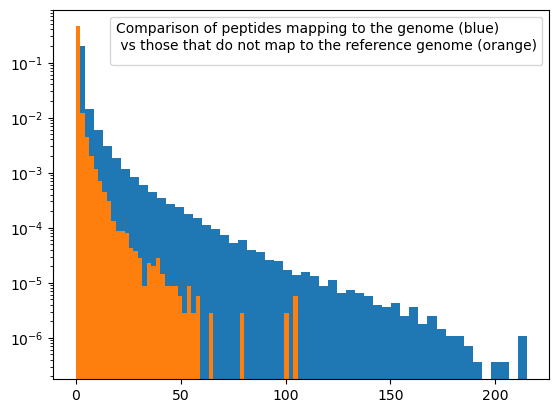

In [20]:
fig = plt.figure()
ax = plt.subplot(111)
ax.hist(pep_main.select("Peptide", "Promiscuity").unique("Peptide").filter(pl.col("Peptide").is_in(pogo_pep_filter["Peptide"])).collect()["Promiscuity"], density=True, bins=50)
ax.hist(pep_main.select("Peptide", "Promiscuity").unique("Peptide").filter(~pl.col("Peptide").is_in(pogo_pep_filter["Peptide"])).collect()["Promiscuity"], density=True, bins = 50, color="tab:orange")
ax.set_yscale("log")
ax.legend(title="Comparison of peptides mapping to the genome (blue)\n vs those that do not map to the reference genome (orange)")

/tmp/ipykernel_3371081/2949139838.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title="Comparison of peptides in iedb (blue)\nand exclusive to carmen (orange)")


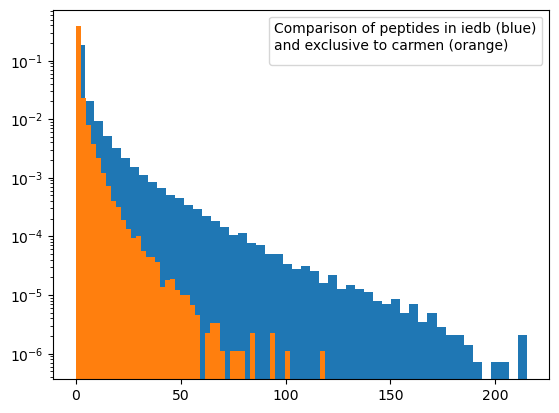

In [21]:
fig = plt.figure()
ax = plt.subplot(111)
ax.hist(iedb_prom["Promiscuity"], density=True, bins=50)
ax.hist(pep_main.select("Peptide", "Promiscuity").unique("Peptide").filter(pl.col("Peptide").is_in(pogo_pep_filter["Peptide"])).join(iedb_pep, left_on="Peptide", right_on="peptide", how="anti").collect()["Promiscuity"], density=True, bins = 50, color="tab:orange")
ax.set_yscale("log")
ax.legend(title="Comparison of peptides in iedb (blue)\nand exclusive to carmen (orange)")

In [31]:
pep_main.select("Peptide", "Promiscuity").unique("Peptide").join(top70_overlap_peptides.lazy(), left_on="Peptide", right_on="column_5", how="semi").collect()

Peptide,Promiscuity
str,f64
"""VSDRQQLEAVY""",1.773087
"""RPSPMQLEL""",11.163711
"""YRPLTVLTF""",3.870606
"""EPCGLRGAL""",2.02083
"""IIVPFGLMY""",0.402567
…,…
"""TTQPTEFKIKL""",0.0
"""GVKGGTKEK""",0.694437
"""SRGLDVEDV""",0.0


Check if we remove peptides that don't map to the genome does the score get different.
It makes sense cause soprano is also looking only at the ones that map to genome right? How they would dn/ds otherwise.

In [95]:
pep_main.select("Peptide", "Promiscuity").unique("Peptide").filter(pl.col("Peptide").is_in(pogo_pep_filter["Peptide"])).join(top70_overlap_peptides.lazy(), left_on="Peptide", right_on="column_5", how="anti").select(pl.len()).collect()


len
u32
401148


In [34]:
pep_main_9m.select("Peptide", "Promiscuity").unique("Peptide").join(top70_overlap_peptides.lazy(), left_on="Peptide", right_on="column_5", how="anti").select(pl.len()).collect()

len
u32
212134


In [37]:
pep_main_not9m = pep_main.filter(pl.col("Peptide").str.len_chars()!=9)

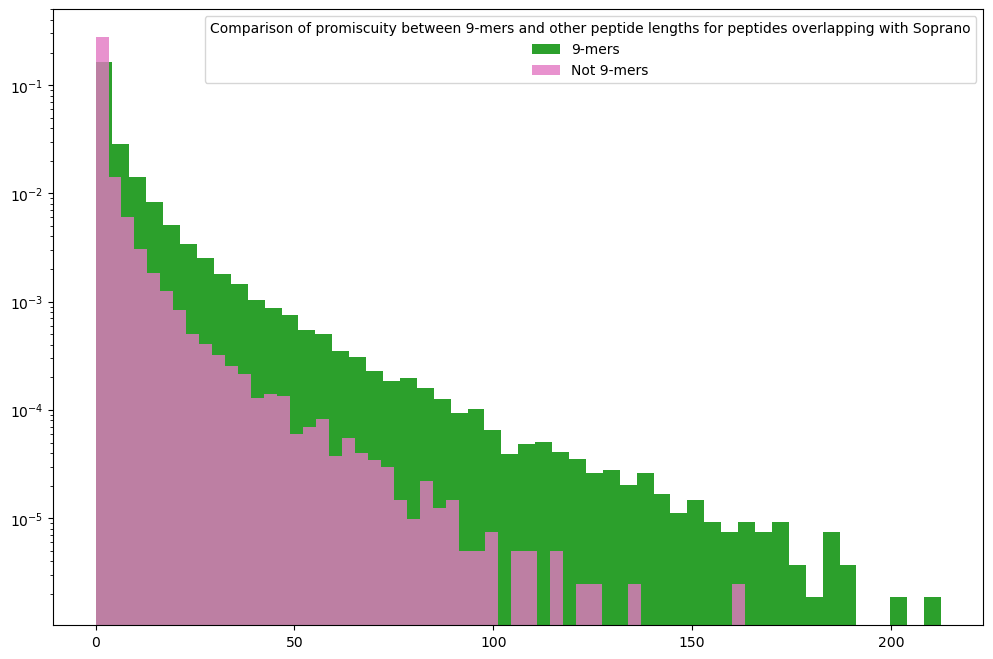

In [41]:
fig = plt.figure(figsize=(12,8))
ax = plt.subplot(111)
ax.hist(pep_main_9m.select("Peptide", "Promiscuity").unique("Peptide").join(top70_overlap_peptides.lazy(), left_on="Peptide", right_on="column_5").collect()["Promiscuity"], density=True, bins=50, color="tab:green", label="9-mers")
ax.hist(pep_main_not9m.select("Peptide", "Promiscuity").unique("Peptide").join(top70_overlap_peptides.lazy(), left_on="Peptide", right_on="column_5").collect()["Promiscuity"], density=True, bins=50, color="tab:pink", label="Not 9-mers", alpha=0.8)
ax.set_yscale("log")
ax.legend(title="Comparison of promiscuity between 9-mers and other peptide lengths for peptides overlapping with Soprano")

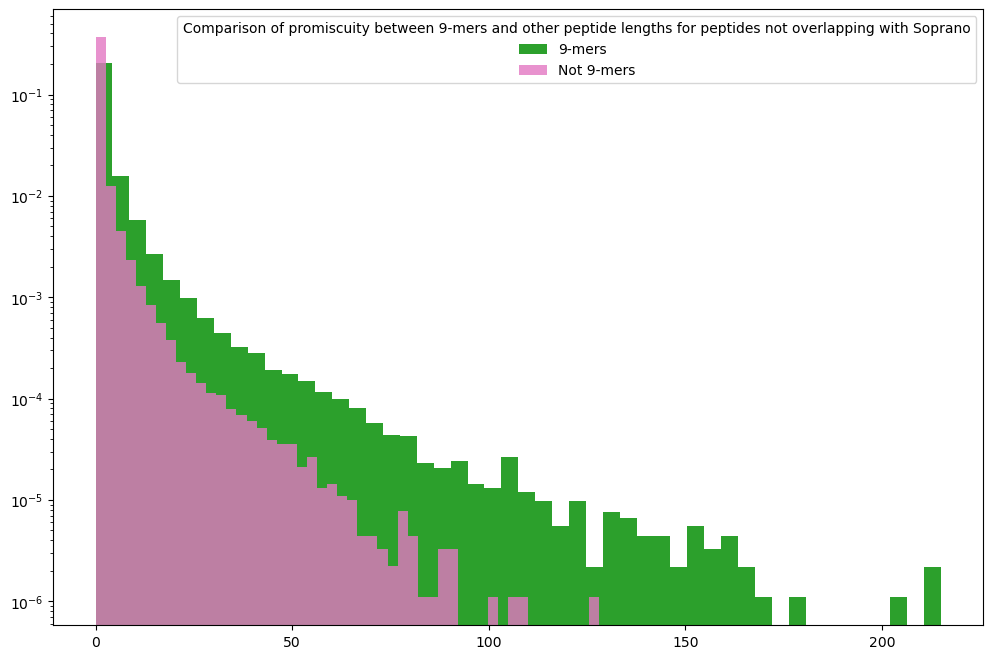

In [39]:
fig = plt.figure(figsize=(12,8))
ax = plt.subplot(111)
ax.hist(pep_main_9m.select("Peptide", "Promiscuity").unique("Peptide").join(top70_overlap_peptides.lazy(), left_on="Peptide", right_on="column_5", how="anti").collect()["Promiscuity"], density=True, bins=50, color="tab:green", label="9-mers")
ax.hist(pep_main_not9m.select("Peptide", "Promiscuity").unique("Peptide").join(top70_overlap_peptides.lazy(), left_on="Peptide", right_on="column_5", how="anti").collect()["Promiscuity"], density=True, bins=50, color="tab:pink", label="Not 9-mers", alpha=0.8)
ax.set_yscale("log")
ax.legend(title="Comparison of promiscuity between 9-mers and other peptide lengths for peptides not overlapping with Soprano")

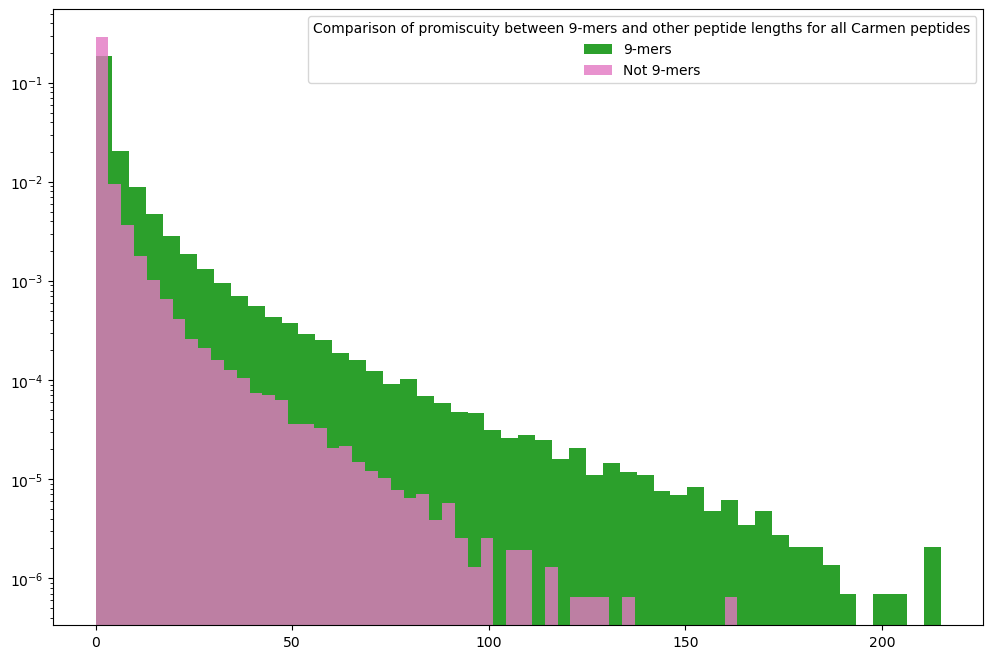

In [38]:
fig = plt.figure(figsize=(12,8))
ax = plt.subplot(111)
ax.hist(pep_main_9m.select("Peptide", "Promiscuity").unique("Peptide").collect()["Promiscuity"], density=True, bins=50, color="tab:green", label="9-mers")
ax.hist(pep_main_not9m.select("Peptide", "Promiscuity").unique("Peptide").collect()["Promiscuity"], density=True, bins=50, color="tab:pink", label="Not 9-mers", alpha=0.8)
ax.set_yscale("log")
ax.legend(title="Comparison of promiscuity between 9-mers and other peptide lengths for all Carmen peptides")
plt.savefig("Carmen_peptides_9mer_vs_other_len_promiscuity_comparison.pdf")

In [96]:
pep_main.select("Peptide", "Promiscuity").unique("Peptide").filter(pl.col("Peptide").is_in(pogo_pep_filter["Peptide"])).join(top70_overlap_peptides.lazy(), left_on="Peptide", right_on="column_5", how="semi").select(pl.len()).collect()

len
u32
250293


In [94]:
pep_main.select("Peptide", "Promiscuity").unique("Peptide").filter(pl.col("Peptide").is_in(pogo_pep_filter["Peptide"])).join(top70_overlap_peptides.lazy(), left_on="Peptide", right_on="column_5", how="anti").collect()["Promiscuity"].mean()


1.6709368433139313

In [17]:
t70carmensop_scores["Promiscuity"].mean()

3.560983455198527

/tmp/ipykernel_3921224/1949996575.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title="Distribution comparison between peptides mapping to the genome exclusive to carmen (orange)\nand those common with peptides from iedb in the soprano analysis (blue)")


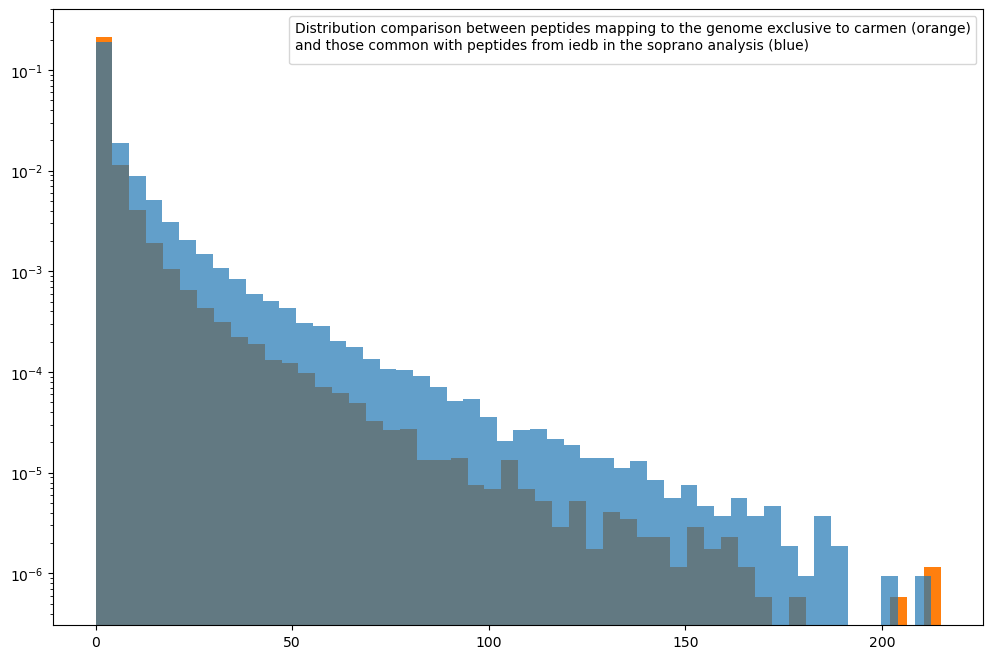

In [42]:
fig=plt.figure(figsize=(12,8))
ax=plt.subplot(111)
ax.hist(pep_main.select("Peptide", "Promiscuity").unique("Peptide").filter(pl.col("Peptide").is_in(pogo_pep_filter["Peptide"])).join(top70_overlap_peptides.lazy(), left_on="Peptide", right_on="column_5", how="anti").collect()["Promiscuity"], density=True, bins = 50, color="tab:orange")
ax.hist(t70carmensop_scores["Promiscuity"], density=True, bins=50, alpha = 0.7)
ax.set_yscale("log")
ax.legend(title="Distribution comparison between peptides mapping to the genome exclusive to carmen (orange)\nand those common with peptides from iedb in the soprano analysis (blue)")
fig.savefig("Carmen_unique_vs_overlapping_with_soprano_predicted_promiscuity.pdf")

In [34]:
0.95*2244

2131.7999999999997

In [45]:
contig_peptides

contig,pep_list,unique_peptides
str,str,i64
"""C1""","""SQELQTFLF""",1
"""C10""","""ELLRKQNL""",1
"""C100""","""ARGPSGLLL,LARGPSGLLL""",2
"""C1000""","""SPSHVVQFR""",1
"""C10000""","""ETIKSISQQ,IELQRNPPP,ISQQSGARI,…",8
…,…,…
"""C99995""","""PFDVVTVTI,VPFDVVTV""",2
"""C99996""","""ASYPLGLGMNK,LYEQAGPSF""",2
"""C99997""","""AHGETLITY,SPAHGETL""",2


In [49]:
bigscore.filter(pl.col("popcov_but_sqrt")>13).join(contig_peptides, left_on="Contigs", right_on="contig").select(pl.col("pep_list").str.split(",")).explode("pep_list").unique()

pep_list
str
"""YDFSQAHNA"""
"""WQRPSKEVEEDEY"""
"""THEGSTVEKTV"""
"""RVEGAQQRWK"""
"""EDLLKEHY"""
…
"""AVVTTTVSSK"""
"""DAFKSGIVQY"""
"""SLNIMRNLVK"""


In [58]:
soprano_top70

column_1,column_2,column_3,column_4,column_5,column_6,npep
str,i64,i64,str,list[str],str,u32
"""chr1""",945112,945146,"""C15""","[""RPLSTRHGV"", ""EGFSERGILR"", ""GILRPLSTR""]","""HLA-A030101,HLA-A680101,HLA-B2…",3
"""chr1""",946173,946268,"""C16""","[""LEDLNFPEI"", ""REEGTPLTL"", … ""KLRDREIQL""]","""HLA-A3301,HLA-A32,HLA-A33,HLA-…",17
"""chr1""",946444,946545,"""C18""","[""KSFLRECKVANY"", ""NYCRQVQQL"", … ""VQQLLGKV""]","""HLA-A030101,HLA-A680101,HLA-B2…",10
"""chr1""",948167,948232,"""C19""","[""QLYDLTLEY"", ""RDGLVEQL"", … ""YRDGLVEQL""]","""HLA-A0201,HLA-A0202,HLA-B1302,…",7
"""chr1""",948499,948561,"""C20""","[""KLSNVNLQEK"", ""SVILKLSNV"", … ""KPINFSVIL""]","""HLA-A0301,HLA-A6801,HLA-B0702,…",4
…,…,…,…,…,…,…
"""chrY""",19741417,19741464,"""C248324""","[""EAICKDRRWAR"", ""RRWARVAQR"", ""RRWARVAQRL""]","""HLA-A3303,HLA-A030101,HLA-A680…",3
"""chrY""",19741801,19741857,"""C248326""","[""EAQTRVKL"", ""ELEAQTRVK"", … ""NYLDQIAKF""]","""HLA-A0206,HLA-A1101,HLA-B5101,…",6
"""chrY""",19744397,19744489,"""C248328""","[""DPLGYIAKI"", ""VFEPSWAEF"", … ""AEFQDPLGYI""]","""HLA-A0101,HLA-B2705,HLA-B4403,…",6


In [63]:
179246/250293

0.716144678436872

In [62]:
soprano_top70.select("column_5").explode("column_5").unique()

column_5
str
"""FLDDLSQKL"""
"""YEVKPFLTAL"""
"""ERLKIRGSL"""
"""FIRTRLLL"""
"""RRQIIGEISK"""
…
"""EVAEYLLQH"""
"""SENVVNRM"""
"""VPNKGYSSL"""


In [71]:
iedb_pep.collect()

peptide
str
"""ARHKIQAKY"""
"""TFPASVLQF"""
"""VTAGGGQILSR"""
"""SLNQQGAHSAL"""
"""ELPSFLGK"""
…
"""APMIKKIAF"""
"""NRVVRNNL"""
"""KSEIAHRFK"""


In [74]:
bigscore.filter(pl.col("popcov_but_sqrt")>13).join(contig_peptides, left_on="Contigs", right_on="contig").select(pl.col("pep_list").str.split(",")).explode("pep_list").unique().lazy().join(iedb_pep, left_on="pep_list", right_on="peptide").collect()

pep_list
str
"""KMALSFVQR"""
"""DTFPTAMHI"""
"""KLKSNQTRTY"""
"""AEEDLRNWI"""
"""LQKVSPVAH"""
…
"""HNLSKIMKL"""
"""DSDINNRLVY"""
"""SVSPDTPVR"""


In [68]:
soprano_top70.select("column_5").explode("column_5").unique().lazy().join(iedb_pep, left_on="column_5", right_on="peptide").collect()

column_5
str
"""NVDSSGNKSVL"""
"""KENMAGKGF"""
"""AEYYDNLPHY"""
"""YIFIPSKF"""
"""YLSERYAEL"""
…
"""QITNLQQHV"""
"""YYVEGVHQQY"""
"""MREGTIGDM"""


In [61]:
bigscore.filter(pl.col("popcov_but_sqrt")>13).join(contig_peptides, left_on="Contigs", right_on="contig").select(pl.col("pep_list").str.split(",")).explode("pep_list").unique().join(soprano_top70.select("column_5").explode("column_5").unique(), left_on="pep_list", right_on="column_5")

pep_list
str
"""LLYRPGHYDILYK"""
"""QDSLSSSL"""
"""GEEERNSVIW"""
"""KMGHTVTVW"""
"""LLRPELEEL"""
…
"""VGDLHPDV"""
"""DIFSYLVEY"""
"""LAAKLLAKY"""


In [38]:
pep_main.filter(pl.col("Promiscuity")>13).select(pl.col("Sample_name").value_counts()).collect()

Sample_name
struct[2]
"{""sample_jurkat_rep2"",3918}"
"{""sample_HCT116-1"",1857}"
"{""sample_AML003_MHC1"",1028}"
"{""sample_20200729_ECL1_OBJ41041_Adaptive_MHC_Targeted_C1R_NoLinker_A0101"",32}"
"{""sample_PXD033935_160610_NT_ATRT8_W632_20__Rep5_25cm90min3s_msms16"",5}"
…
"{""sample_F120180817_KP_THP1_BB72_P3"",319}"
"{""sample_MSB35123"",5}"
"{""sample_PXD033935_160610_NT_ATRT9_W632_20__Rep1_25cm90min3s_msms3"",185}"


In [61]:
soprano_top70["column_4"].unique()

column_4
str
"""C142657"""
"""C227326"""
"""C235073"""
"""C57040"""
"""C111169"""
…
"""C139665"""
"""C19745"""
"""C141028"""


In [81]:
t70carmen_scores.max()

pep_list,Study_id,Sample_name,Peptide_type,Spectral_count,Assigned_modifications,Haplotype,Netmhcpan_binder,Promiscuity
str,str,str,str,i64,str,str,str,f64
"""YYYGIKDLATVF""","""PXD034772""","""sample_T1""","""canonical""",26,"""N-term(42.0106)""",null,null,13.068715


In [46]:
top70_overlap_peptides

column_5
str
"""STMERWGQK"""
"""STQSKVMNK"""
"""RLAKVHAYII"""
"""GPDKGLVKEVL"""
"""RPQRATSNVF"""
…
"""YFDTAVSRPGRGEPR"""
"""IAVQAVLAL"""
"""DEAGPSIVHRK"""


In [47]:
soprano_top70.join(con)

column_1,column_2,column_3,column_4,column_5,column_6,npep
str,i64,i64,str,list[str],str,u32
"""chr1""",945112,945146,"""C15""","[""RPLSTRHGV"", ""EGFSERGILR"", ""GILRPLSTR""]","""HLA-A030101,HLA-A680101,HLA-B2…",3
"""chr1""",946173,946268,"""C16""","[""KLRDREIQL"", ""TREEGTPL"", … ""TREEGTPLTL""]","""HLA-A3301,HLA-A32,HLA-A33,HLA-…",17
"""chr1""",946444,946545,"""C18""","[""FPELVLPVVL"", ""GKVQENSAY"", … ""KVANYCRQV""]","""HLA-A030101,HLA-A680101,HLA-B2…",10
"""chr1""",948167,948232,"""C19""","[""YRDGLVEQL"", ""YLHSQAHCI"", … ""QLYDLTLEYL""]","""HLA-A0201,HLA-A0202,HLA-B1302,…",7
"""chr1""",948499,948561,"""C20""","[""KPINFSVIL"", ""KLSNVNLQEK"", … ""SVILKLSNV""]","""HLA-A0301,HLA-A6801,HLA-B0702,…",4
…,…,…,…,…,…,…
"""chrY""",19741417,19741464,"""C248324""","[""RRWARVAQRL"", ""RRWARVAQR"", ""EAICKDRRWAR""]","""HLA-A3303,HLA-A030101,HLA-A680…",3
"""chrY""",19741801,19741857,"""C248326""","[""EAQTRVKL"", ""NYLDQIAKF"", … ""LEAQTRVKL""]","""HLA-A0206,HLA-A1101,HLA-B5101,…",6
"""chrY""",19744397,19744489,"""C248328""","[""VFEPSWAEF"", ""AEFQDPLGY"", … ""RPIAEKSGI""]","""HLA-A0101,HLA-B2705,HLA-B4403,…",6


# t6 analysis

In [43]:
soprano_t6 = pl.read_csv(soprano_top6_bed, separator="\t", has_header=False)
soprano_t6 = soprano_t6.with_columns(pl.col("column_5").str.split(",").list.unique()).with_columns(npep = pl.col("column_5").list.len())
t6_overlap_peptides = soprano_t6.select("column_5").explode("column_5").unique()
t6_all_possible_peptides = soprano_t6.join(contig_peptides, left_on="column_4", right_on="contig").with_columns(pl.col("pep_list").str.split(",").list.unique()).select("pep_list").explode("pep_list").unique()
t6_carmen_only = t6_all_possible_peptides.join(t6_overlap_peptides, left_on="pep_list", right_on="column_5", how="anti")
t6carmensop_scores = t6_overlap_peptides.lazy().join(pep_main.unique("Peptide"), left_on="column_5", right_on="Peptide", how="left", coalesce=True).collect()
t6carmen_scores = t6_carmen_only.lazy().join(pep_main, left_on="pep_list", right_on="Peptide").collect()

In [45]:
t6_overlap_peptides.filter(pl.col("column_5").str.len_chars()!=9)

column_5
str
"""NAANVGWNNSTF"""
"""FSFDYRAATQFWRSK"""
"""VRFRIGGKRK"""
"""SDSTHVTF"""
"""EKAAMPVA"""
…
"""YPAVSAVY"""
"""ARLKSKDVKL"""
"""SQDIYLRL"""


In [27]:
t6_overlap_peptides.unique()

column_5
str
"""SLSDLHKFCL"""
"""LPFLSSSNL"""
"""SEHSTEGSVSL"""
"""ADKVPKTAENF"""
"""VVVNPQTKR"""
…
"""LFVHVHHLI"""
"""DKYHPGYFGK"""
"""DRYFRIQEV"""


In [29]:
t6_overlap_peptides.lazy().join(pep_main, left_on="column_5", right_on="Peptide").group_by("Sample_name").agg().collect()

Sample_name
str
"""sample_smallintestine_W6_008"""
"""sample_20200729_ECL1_OBJ41041_…"
"""sample_Lumos_190225_HA"""
"""sample_FL707_IPP85_Xu_DOTC2_MH…"
"""sample_AML016_MHC1"""
…
"""sample_AML009_MHC1"""
"""sample_20200202_ECL2_OBJ41389_…"
"""sample_20200814_ECL1_OBJ41041_…"


In [30]:
t6_all_possible_peptides.lazy().join(pep_main, left_on="pep_list", right_on="Peptide").group_by("Sample_name").agg().collect()

Sample_name
str
"""sample_ovary_W6_006"""
"""sample_20190221_QE_HFX2_LC3_SA…"
"""sample_210614_JB_HepG2_1_p1011…"
"""sample_2069_L_MdB076_17mei19_d…"
"""sample_PXD033935_170116_AM_ATR…"
…
"""sample_Donor_5_Treg_MHC1"""
"""sample_20180509_QEh1_LC1_SA_JM…"
"""sample_20210429_ECL2_OBJ41515_…"


In [31]:
t6_carmen_only.lazy().join(pep_main, left_on="pep_list", right_on="Peptide").group_by("Sample_name").agg().collect()

Sample_name
str
"""sample_20191212_COL011_00016_H…"
"""sample_PXD033935_170121_AM_ATR…"
"""sample_20200124_Lum2_IO_U3000_…"
"""sample_20200828_COL011_00057_H…"
"""sample_Mel-38_HLA-I"""
…
"""sample_20200729_ECL1_OBJ41041_…"
"""sample_20200729_ECL1_OBJ41041_…"
"""sample_20201202_Lum2_IO_U3000_…"


In [38]:
pep_main.fetch(2)

Study_id,Sample_name,Peptide,Peptide_type,Spectral_count,Assigned_modifications,Haplotype,Netmhcpan_binder,Promiscuity
str,str,str,str,i64,str,str,str,f64
"""MSV000080527-84172-84442""","""sample_A0101""","""AADIFYSRY""","""canonical""",12,null,"""A*01:01""","""Y""",0.688129
"""MSV000080527-84172-84442""","""sample_A0101""","""AADLNLVLY""","""canonical""",14,null,"""A*01:01""","""Y""",8.672632


In [49]:
t6_carmen_only.lazy().join(pep_main, left_on="pep_list", right_on="Peptide").group_by("Sample_name").agg(pl.len()).collect()

Sample_name,len
str,u32
"""sample_20210521_ECL2_OBJ41515_…",1
"""sample_20210426_Lum2_IO_U3000_…",82
"""sample_20200131_Lum2_IO_U3000_…",4
"""sample_PXD033935_170121_AM_ATR…",33
"""sample_20200124_Lum2_IO_U3000_…",3
…,…
"""sample_20210508_Lum2_IO_U3000_…",65
"""sample_Donor_3_Treg_MHC1""",3
"""sample_20200729_ECL1_OBJ41041_…",2


In [39]:
t6_overlap_peptides.lazy().join(pep_main, left_on="column_5", right_on="Peptide").group_by("Sample_name").agg(pl.len()).collect()

Sample_name,len
str,u32
"""sample_tongue_W6_006""",1078
"""sample_20210413_ECL2_OBJ41515_…",1024
"""sample_16H145_3""",750
"""sample_CRC-01-untreated1-HLA-I""",7140
"""sample_20191212_COL011_00016_H…",29
…,…
"""sample_HCC030_Tumor""",262
"""sample_20210512_ECL2_OBJ41515_…",5
"""sample_20190221_QE_HFX2_LC3_SA…",221


In [44]:
percent_remaining = []
oglen = pep_main.select(pl.col("Peptide").unique()).select(pl.len()).collect().item()
for threshold in range(1,214):
    peptidesrm = pep_main.filter(pl.col("Promiscuity")>threshold).select(pl.col("Peptide").unique()).select(pl.len()).collect().item()
    percent_remaining.append(peptidesrm/oglen)

In [45]:
percent_overlap = []
for threshold in range(1,214):
    peptidesig = pep_main.filter(pl.col("Promiscuity")>threshold).select(pl.col("Peptide").unique()).select(pl.len()).collect().item()
    peptidesol = t6_overlap_peptides.lazy().join(pep_main.filter(pl.col("Promiscuity")>threshold).select(pl.col("Peptide").unique()), right_on="Peptide", left_on="column_5").select(pl.len()).collect().item()
    percent_overlap.append(peptidesol/peptidesig)

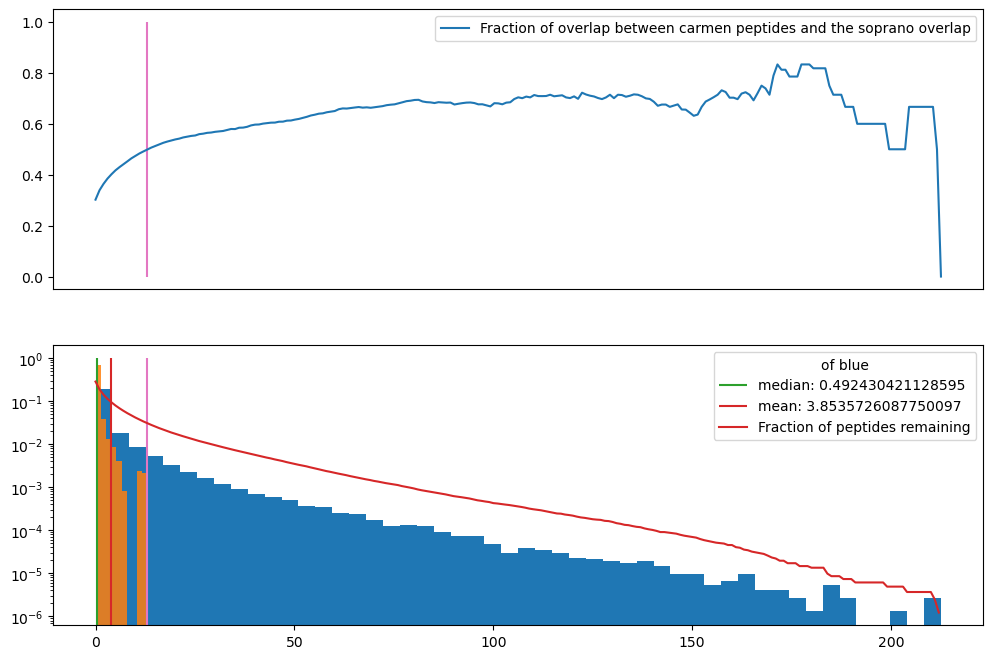

In [46]:
fig = plt.figure(figsize=(12,8))
ax1 = plt.subplot(211)
ax1.vlines(13,0,1,color="tab:pink")
ax1.plot(percent_overlap, label="Fraction of overlap between carmen peptides and the soprano overlap")
ax1.legend()
ax1.set_xticklabels([])
ax1.set_xticks([])
ax = plt.subplot(212)
ax.hist(t6carmensop_scores["Promiscuity"], density=True, bins=50)
ax.vlines(t6carmensop_scores["Promiscuity"].median(), 0, 1, color="tab:green", label=f"median: {t6carmensop_scores['Promiscuity'].median()}")
ax.vlines(t6carmensop_scores["Promiscuity"].mean(), 0, 1, color="tab:red", label=f"mean: {t6carmensop_scores['Promiscuity'].mean()}")
ax.vlines(13,0,1,color="tab:pink")
ax.hist(t6carmen_scores["Promiscuity"], density=True, color="tab:orange", alpha=0.85)
ax.plot(percent_remaining, color="tab:red", label="Fraction of peptides remaining")
ax.legend(title="of blue")
ax.set_yscale("log")
fig.savefig("Carmen_comparison_of_predicted_vs_detected_peptides_promiscuity_top6HLAs.pdf")

In [48]:
soprano_t6 = pl.read_csv(soprano_top6_bed, separator="\t", has_header=False)
soprano_t6 = soprano_t6.with_columns(pl.col("column_5").str.split(",").list.unique()).with_columns(npep = pl.col("column_5").list.len())
t6_overlap_peptides_9m = soprano_t6.select("column_5").explode("column_5").unique().filter(pl.col("column_5").str.len_chars()==9)
t6_all_possible_peptides_9m = soprano_t6.join(contig_peptides, left_on="column_4", right_on="contig").with_columns(pl.col("pep_list").str.split(",").list.unique()).select("pep_list").explode("pep_list").unique().filter(pl.col("pep_list").str.len_chars()==9)
t6_carmen_only_9m = t6_all_possible_peptides_9m.join(t6_overlap_peptides_9m, left_on="pep_list", right_on="column_5", how="anti")
t6carmensop_scores_9m = t6_overlap_peptides_9m.lazy().join(pep_main_9m.unique("Peptide"), left_on="column_5", right_on="Peptide", how="left", coalesce=True).collect()
t6carmen_scores_9m = t6_carmen_only_9m.lazy().join(pep_main_9m, left_on="pep_list", right_on="Peptide").collect()

In [9]:
t6_all_possible_peptides_9m.lazy().join(pep_main, left_on="pep_list", right_on="Peptide").group_by("Sample_name").agg(pl.len()).collect()

Sample_name,len
str,u32
"""sample_P3_N""",36
"""sample_Donor_6_expanded_MHC1""",3253
"""sample_PXD027182_NB8_PASEGA_0B…",185
"""sample_20210512_ECL2_OBJ41515_…",3
"""sample_C0202""",658
…,…
"""sample_PXD027182_NB_1691_PDX_W…",82
"""sample_2069_L_MdB076_17mei19_d…",1249
"""sample_PXD014397_LM44_noIFN_DT…",309


In [19]:
t6_overlap_peptides.join(t6_overlap_peptides_9m, on="column_5", how="anti")

column_5
str
"""PIPYEFMA"""
"""VVLGIRPIRL"""
"""SRASSIIDELFQDRF"""
"""KDFLSVML"""
"""FPMGSTVLDQQL"""
…
"""RAFDQGADAIY"""
"""LPKEDPTAVA"""
"""FPVGDAVSKVL"""


In [10]:
t6_overlap_peptides_9m.lazy().join(pep_main, left_on="column_5", right_on="Peptide").group_by("Sample_name").agg().collect()

Sample_name
str
"""sample_B4002"""
"""sample_PXD014397_F120190619_PF…"
"""sample_F20180830_KP_THP1_BB72_…"
"""sample_20210426_Lum2_IO_U3000_…"
"""sample_20220718_ECL2_OBJ41515_…"
…
"""sample_PXD025716_PBMC_29_Rep_3"""
"""sample_20210413_ECL2_OBJ41515_…"
"""sample_F120180713_KP_THP1_BB72…"


In [16]:
t6_carmen_only_9m

pep_list
str
"""SEFKKMLGF"""
"""GSIRYEALK"""
"""TAHRPIDHW"""
"""LPYKITAEE"""
"""TYIGSVELV"""
…
"""AEEICSASW"""
"""EFYHPGQEY"""
"""IKDGLIIRK"""


In [15]:
t6_overlap_peptides_9m

column_5
str
"""LENQNKTLI"""
"""YLMRANITA"""
"""VTFVPGLYK"""
"""LMSQVIKDK"""
"""AQVRGGYVL"""
…
"""AVNGVQLHY"""
"""MLDLFFHYV"""
"""DLNFPEIKR"""


In [18]:
percent_remaining_9m = []
oglen = pep_main_9m.select(pl.col("Peptide").unique()).select(pl.len()).collect().item()
for threshold in range(1,214):
    peptidesrm = pep_main_9m.filter(pl.col("Promiscuity")>threshold).select(pl.col("Peptide").unique()).select(pl.len()).collect().item()
    percent_remaining_9m.append(peptidesrm/oglen)

In [49]:
percent_overlap_9m = []
for threshold in range(1,214):
    peptidesig = pep_main_9m.filter(pl.col("Promiscuity")>threshold).select(pl.col("Peptide").unique()).select(pl.len()).collect().item()
    peptidesol = t6_overlap_peptides_9m.lazy().join(pep_main_9m.filter(pl.col("Promiscuity")>threshold).select(pl.col("Peptide").unique()), right_on="Peptide", left_on="column_5").select(pl.len()).collect().item()
    percent_overlap_9m.append(peptidesol/peptidesig)

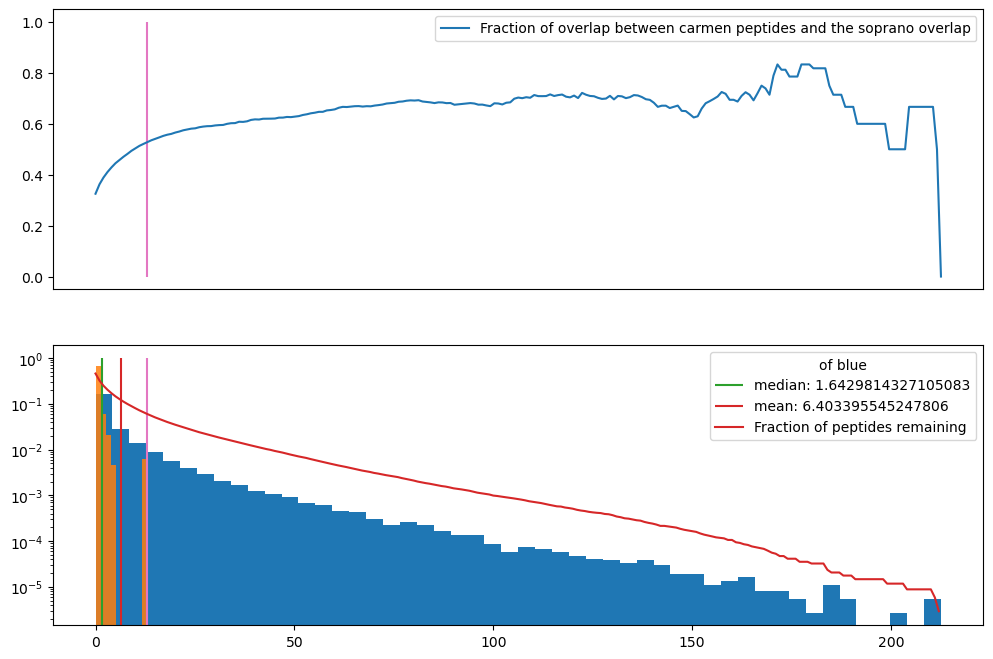

In [50]:
fig = plt.figure(figsize=(12,8))
ax1 = plt.subplot(211)
ax1.vlines(13,0,1,color="tab:pink")
ax1.plot(percent_overlap_9m, label="Fraction of overlap between carmen peptides and the soprano overlap")
ax1.legend()
ax1.set_xticklabels([])
ax1.set_xticks([])
ax = plt.subplot(212)
ax.hist(t6carmensop_scores_9m["Promiscuity"], density=True, bins=50)
ax.vlines(t6carmensop_scores_9m["Promiscuity"].median(), 0, 1, color="tab:green", label=f"median: {t6carmensop_scores_9m['Promiscuity'].median()}")
ax.vlines(t6carmensop_scores_9m["Promiscuity"].mean(), 0, 1, color="tab:red", label=f"mean: {t6carmensop_scores_9m['Promiscuity'].mean()}")
ax.vlines(13,0,1,color="tab:pink")
ax.hist(t6carmen_scores_9m["Promiscuity"], density=True, color="tab:orange", alpha=0.85)
ax.plot(percent_remaining_9m, color="tab:red", label="Fraction of peptides remaining")
ax.legend(title="of blue")
ax.set_yscale("log")
fig.savefig("Carmen_comparison_of_predicted_vs_detected_peptides_promiscuity_top6HLAs_9mers_only.pdf")

In [15]:
percent_overlap = []
for threshold in range(1,214):
    peptidesig = pep_main.filter(pl.col("Promiscuity")>threshold).select(pl.col("Peptide").unique()).select(pl.len()).collect().item()
    peptidesol = t6_overlap_peptides.lazy().join(pep_main.filter(pl.col("Promiscuity")>threshold).select(pl.col("Peptide").unique()), right_on="Peptide", left_on="column_5").select(pl.len()).collect().item()
    percent_overlap.append(peptidesol/peptidesig)

In [ ]:
soprano_t6 = pl.read_csv(soprano_top6_bed, separator="\t", has_header=False)
soprano_t6 = soprano_t6.with_columns(pl.col("column_5").str.split(",").list.unique()).with_columns(npep = pl.col("column_5").list.len())
t6_overlap_peptides = soprano_t6.select("column_5").explode("column_5").unique()
t6_all_possible_peptides = soprano_t6.join(contig_peptides, left_on="column_4", right_on="contig").with_columns(pl.col("pep_list").str.split(",").list.unique()).select("pep_list").explode("pep_list").unique()
t6_carmen_only = t6_all_possible_peptides.join(t6_overlap_peptides, left_on="pep_list", right_on="column_5", how="anti")
t6carmensop_scores = t6_overlap_peptides.lazy().join(pep_main.unique("Peptide"), left_on="column_5", right_on="Peptide", how="left", coalesce=True).collect()
t6carmen_scores = t6_carmen_only.lazy().join(pep_main, left_on="pep_list", right_on="Peptide").collect()
fig = plt.figure(figsize=(12,8))
ax = plt.subplot(111)
ax.hist(t6carmensop_scores["Promiscuity"], density=True, bins=50)
ax.vlines(t6carmensop_scores["Promiscuity"].median(), 0, 1, color="tab:green", label=f"median: {t6carmensop_scores['Promiscuity'].median()}")
ax.vlines(t6carmensop_scores["Promiscuity"].mean(), 0, 1, color="tab:red", label=f"mean: {t6carmensop_scores['Promiscuity'].mean()}")
ax.hist(t6carmen_scores["Promiscuity"], density=True, color="tab:orange", alpha=0.85)
ax.legend(title="of blue")
ax.plot(percent_overlap)
ax.plot(percent_remaining, color="tab:red")
#ax.set_yscale("log")

In [31]:
soprano_t6.join(bigscore, left_on="column_4", right_on="Contigs")["popcov_but_sqrt"].mean()

46.91299805225877

In [20]:
bigscore.filter(~pl.col("Contigs").is_in(soprano_t6["column_4"]))["popcov_but_sqrt"].mean()

4.987230559581247

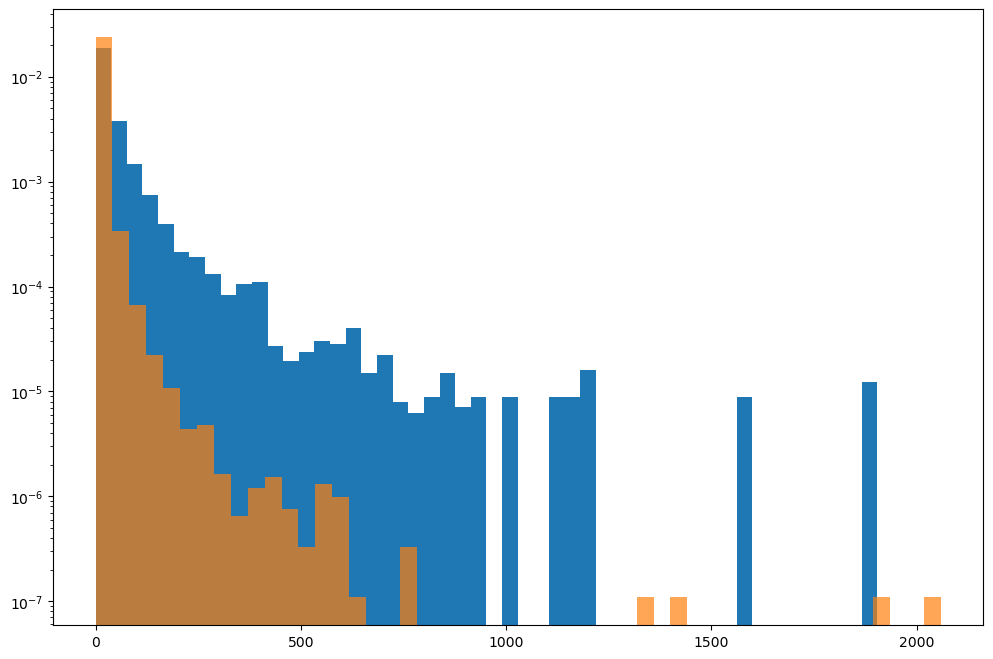

In [17]:
fig = plt.figure(figsize=(12,8))
ax = plt.subplot(111)
ax.hist(soprano_t6.join(bigscore, left_on="column_4", right_on="Contigs")["popcov_but_sqrt"], density=True, bins=50)
ax.hist(bigscore.filter(~pl.col("Contigs").is_in(soprano_t6["column_4"]))["popcov_but_sqrt"], density=True, color="tab:orange", alpha=0.7, bins=50)
ax.set_yscale("log")

In [60]:
soprano_t6["column_4"].unique()

column_4
str
"""C45455"""
"""C74465"""
"""C77465"""
"""C91959"""
"""C49320"""
…
"""C39114"""
"""C208795"""
"""C158987"""


In [80]:
t6carmen_scores.max()

pep_list,Study_id,Sample_name,Peptide_type,Spectral_count,Assigned_modifications,Haplotype,Netmhcpan_binder,Promiscuity
str,str,str,str,i64,str,str,str,f64
"""YYYGIKDLATVF""","""PXD034772""","""sample_T1""","""canonical""",22,"""N-term(42.0106)""",null,null,13.068715


NameError: name 'percent_remaining' is not defined

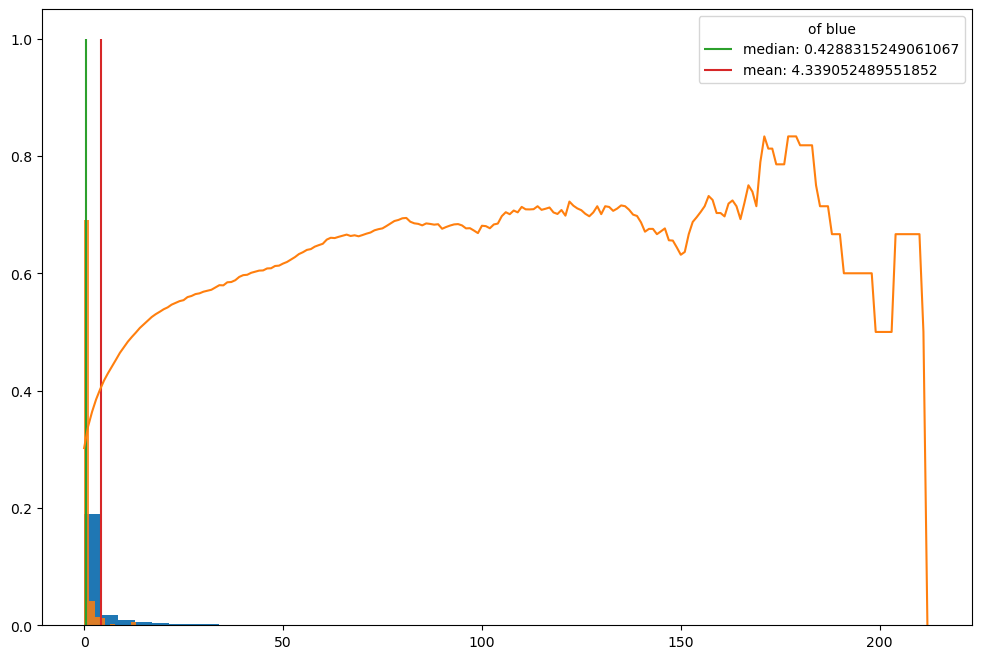

In [23]:
soprano_a0201 = pl.read_csv(soprano_A0201_bed, separator="\t", has_header=False)
soprano_a0201 = soprano_a0201.with_columns(pl.col("column_5").str.split(",").list.unique()).with_columns(npep = pl.col("column_5").list.len())
a0201_overlap_peptides = soprano_a0201.select("column_5").explode("column_5").unique()
a0201_all_possible_peptides = soprano_a0201.join(contig_peptides, left_on="column_4", right_on="contig").with_columns(pl.col("pep_list").str.split(",").list.unique()).select("pep_list").explode("pep_list").unique()
a0201_carmen_only = a0201_all_possible_peptides.join(a0201_overlap_peptides, left_on="pep_list", right_on="column_5", how="anti")
a0201carmensop_scores = a0201_overlap_peptides.lazy().join(pep_main.unique("Peptide"), left_on="column_5", right_on="Peptide", how="left", coalesce=True).collect()
a0201carmen_scores = a0201_carmen_only.lazy().join(pep_main, left_on="pep_list", right_on="Peptide").collect()
fig = plt.figure(figsize=(12,8))
ax = plt.subplot(111)
ax.hist(a0201carmensop_scores["Promiscuity"], density=True, bins=50)
ax.vlines(a0201carmensop_scores["Promiscuity"].median(), 0, 1, color="tab:green", label=f"median: {a0201carmensop_scores['Promiscuity'].median()}")
ax.vlines(a0201carmensop_scores["Promiscuity"].mean(), 0, 1, color="tab:red", label=f"mean: {a0201carmensop_scores['Promiscuity'].mean()}")
ax.hist(a0201carmen_scores["Promiscuity"], density=True, color="tab:orange", alpha=0.85)
ax.legend(title="of blue")
ax.plot(percent_overlap)
ax.plot(percent_remaining, color="tab:red")
#ax.set_yscale("log")

# A0201 analysis

In [51]:
soprano_a0201 = pl.read_csv(soprano_A0201_bed, separator="\t", has_header=False)
soprano_a0201 = soprano_a0201.with_columns(pl.col("column_5").str.split(",").list.unique()).with_columns(npep = pl.col("column_5").list.len())
a0201_overlap_peptides = soprano_a0201.select("column_5").explode("column_5").unique()
a0201_all_possible_peptides = soprano_a0201.join(contig_peptides, left_on="column_4", right_on="contig").with_columns(pl.col("pep_list").str.split(",").list.unique()).select("pep_list").explode("pep_list").unique()
a0201_carmen_only = a0201_all_possible_peptides.join(a0201_overlap_peptides, left_on="pep_list", right_on="column_5", how="anti")
a0201carmensop_scores = a0201_overlap_peptides.lazy().join(pep_main.unique("Peptide"), left_on="column_5", right_on="Peptide", how="left", coalesce=True).collect()
a0201carmen_scores = a0201_carmen_only.lazy().join(pep_main, left_on="pep_list", right_on="Peptide").collect()

In [15]:
a0201_all_possible_peptides.lazy().join(pep_main, left_on="pep_list", right_on="Peptide").group_by("Sample_name").agg().collect()

Sample_name
str
"""sample_PXD025345_191218PK_361_…"
"""sample_20200828_COL011_00056_H…"
"""sample_PXD025716_AML_07_Rep_8"""
"""sample_Mel-27_HLA-I"""
"""sample_PXD033935_160719_NT_ATR…"
…
"""sample_PXD014397_F120190409_PF…"
"""sample_PXD033935_170121_AM_ATR…"
"""sample_A3601"""


In [12]:
a0201_overlap_peptides.lazy().join(pep_main, left_on="column_5", right_on="Peptide").group_by("Sample_name").agg().collect()

Sample_name
str
"""sample_PXD014397_F120190409_PF…"
"""sample_20200124_Lum2_IO_U3000_…"
"""sample_spleen_W6_009"""
"""sample_20200131_Lum2_IO_U3000_…"
"""sample_PXD014397_F120190619_PF…"
…
"""sample_Pool_4_Treg_MHC1"""
"""sample_210531_JB_SMMC_3_p1431_…"
"""sample_VY20210319_HT_CPTAC8_Cl…"


In [10]:
a0201_overlap_peptides

column_5
str
"""REENRTKTL"""
"""DVVSKIYI"""
"""FIDPKKIKV"""
"""IPKLVADFM"""
"""YLEINPLVV"""
…
"""TYFPHFDLS"""
"""YSVSYLLKDKGEYTL"""
"""KVLENIELNK"""


In [11]:
a0201_carmen_only

pep_list
str
"""LPMKEGCTEV"""
"""GQCPMRVQK"""
"""SMGLPTSDEQK"""
"""FLLDGLHEDLNRV"""
"""VLTNSPVELREPNVL"""
…
"""DATYTSAR"""
"""YEKEKLNER"""
"""GQVLNIQMR"""


In [52]:
percent_overlap = []
for threshold in range(1,214):
    peptidesig = pep_main.filter(pl.col("Promiscuity")>threshold).select(pl.col("Peptide").unique()).select(pl.len()).collect().item()
    peptidesol = a0201_overlap_peptides.lazy().join(pep_main.filter(pl.col("Promiscuity")>threshold).select(pl.col("Peptide").unique()), right_on="Peptide", left_on="column_5").select(pl.len()).collect().item()
    percent_overlap.append(peptidesol/peptidesig)

In [8]:
percent_remaining = []
oglen = pep_main.select(pl.col("Peptide").unique()).select(pl.len()).collect().item()
for threshold in range(1,214):
    peptidesrm = pep_main.filter(pl.col("Promiscuity")>threshold).select(pl.col("Peptide").unique()).select(pl.len()).collect().item()
    percent_remaining.append(peptidesrm/oglen)

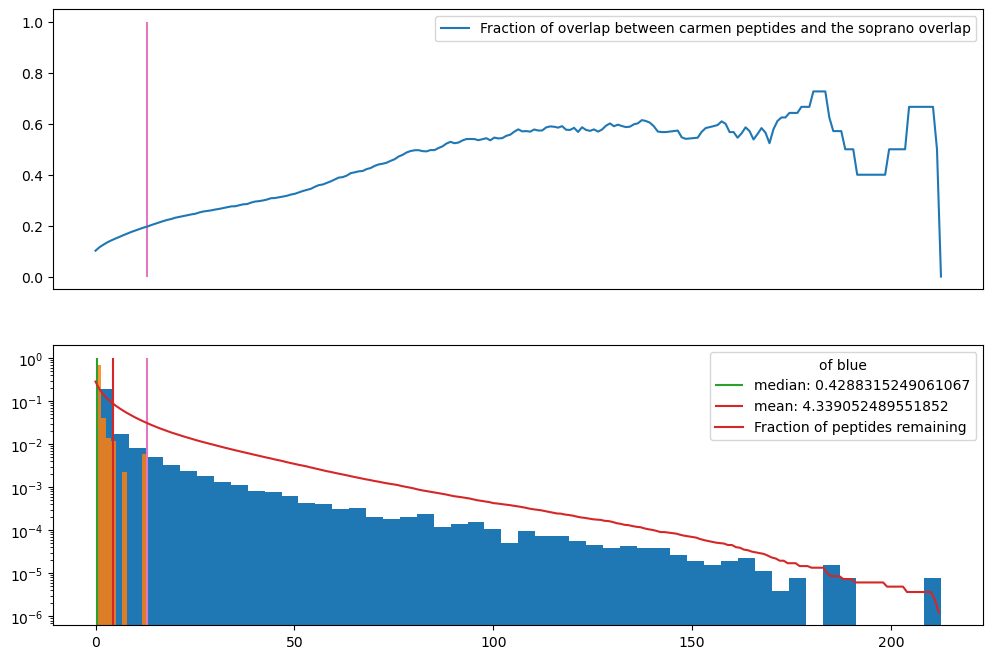

In [53]:
fig = plt.figure(figsize=(12,8))
ax1 = plt.subplot(211)
ax1.vlines(13,0,1,color="tab:pink")
ax1.plot(percent_overlap, label="Fraction of overlap between carmen peptides and the soprano overlap")
ax1.legend()
ax1.set_xticklabels([])
ax1.set_xticks([])
ax = plt.subplot(212)
ax.hist(a0201carmensop_scores["Promiscuity"], density=True, bins=50)
ax.vlines(a0201carmensop_scores["Promiscuity"].median(), 0, 1, color="tab:green", label=f"median: {a0201carmensop_scores['Promiscuity'].median()}")
ax.vlines(a0201carmensop_scores["Promiscuity"].mean(), 0, 1, color="tab:red", label=f"mean: {a0201carmensop_scores['Promiscuity'].mean()}")
ax.vlines(13,0,1,color="tab:pink")
ax.hist(a0201carmen_scores["Promiscuity"], density=True, color="tab:orange", alpha=0.85)
ax.plot(percent_remaining, color="tab:red", label="Fraction of peptides remaining")
ax.legend(title="of blue")
ax.set_yscale("log")
fig.savefig("Carmen_comparison_of_predicted_vs_detected_peptides_promiscuity_a0201.pdf")

# A0201 analysis 9-mer

In [54]:
soprano_a0201 = pl.read_csv(soprano_A0201_bed, separator="\t", has_header=False)
soprano_a0201 = soprano_a0201.with_columns(pl.col("column_5").str.split(",").list.unique()).with_columns(npep = pl.col("column_5").list.len())
a0201_overlap_peptides_9m = soprano_a0201.select("column_5").explode("column_5").unique().filter(pl.col("column_5").str.len_chars()==9)
a0201_all_possible_peptides_9m = soprano_a0201.join(contig_peptides, left_on="column_4", right_on="contig").with_columns(pl.col("pep_list").str.split(",").list.unique()).select("pep_list").explode("pep_list").unique().filter(pl.col("pep_list").str.len_chars()==9)
a0201_carmen_only_9m = a0201_all_possible_peptides_9m.join(a0201_overlap_peptides_9m, left_on="pep_list", right_on="column_5", how="anti")
a0201carmensop_scores_9m = a0201_overlap_peptides_9m.lazy().join(pep_main_9m.unique("Peptide"), left_on="column_5", right_on="Peptide", how="left", coalesce=True).collect()
a0201carmen_scores_9m = a0201_carmen_only_9m.lazy().join(pep_main_9m, left_on="pep_list", right_on="Peptide").collect()

In [20]:
a0201_all_possible_peptides_9m.lazy().join(pep_main, left_on="pep_list", right_on="Peptide").group_by("Sample_name").agg().collect()

Sample_name
str
"""sample_PXD025716_AML_01_Rep_1"""
"""sample_C1R-C0304"""
"""sample_smallintestine_W6_010"""
"""sample_20200729_ECL1_OBJ41041_…"
"""sample_PXD014397_F120190619_PF…"
…
"""sample_2064_L_MdB072_7mei19_do…"
"""sample_liver_W6_003"""
"""sample_PXD014397_F120190129_PF…"


In [21]:
a0201_overlap_peptides_9m.lazy().join(pep_main, left_on="column_5", right_on="Peptide").group_by("Sample_name").agg().collect()

Sample_name
str
"""sample_20200131_Lum2_IO_U3000_…"
"""sample_VY20210319_HT_CPTAC6_Cl…"
"""sample_20210413_ECL2_OBJ41515_…"
"""sample_PXD025716_CLL_14_Rep_3"""
"""sample_T1"""
…
"""sample_PXD025345_231_II_EV_231…"
"""sample_F120180713_KP_THP1_w632…"
"""sample_PXD025345_191210_CB5"""


In [24]:
a0201_overlap_peptides.join(a0201_overlap_peptides_9m, on="column_5", how="anti")

column_5
str
"""DVVSKIYI"""
"""LHQEGAKM"""
"""RTLSSSTQASI"""
"""ALGPRWAL"""
"""SGVSLAALKK"""
…
"""HAVDGNTVELKR"""
"""SRFKKRML"""
"""YSVSYLLKDKGEYTL"""


In [22]:
a0201_overlap_peptides_9m

column_5
str
"""ILDDVCATM"""
"""LPPHIIRLV"""
"""RDVEFLVQL"""
"""NFKAFASLR"""
"""FLETNVPLL"""
…
"""SPRAGAREL"""
"""RLQGELQAV"""
"""RTYEKFFGL"""


In [23]:
a0201_carmen_only_9m

pep_list
str
"""QAFIDFMSR"""
"""SESKDTELA"""
"""NVPQFCDSL"""
"""KHFSVEGQL"""
"""TEKKQKSIL"""
…
"""SYLEDKVYL"""
"""KSSKMLQHI"""
"""PVSNMAMAY"""


In [55]:
percent_overlap_9m = []
for threshold in range(1,214):
    peptidesig = pep_main_9m.filter(pl.col("Promiscuity")>threshold).select(pl.col("Peptide").unique()).select(pl.len()).collect().item()
    peptidesol = a0201_overlap_peptides.lazy().join(pep_main_9m.filter(pl.col("Promiscuity")>threshold).select(pl.col("Peptide").unique()), right_on="Peptide", left_on="column_5").select(pl.len()).collect().item()
    percent_overlap_9m.append(peptidesol/peptidesig)

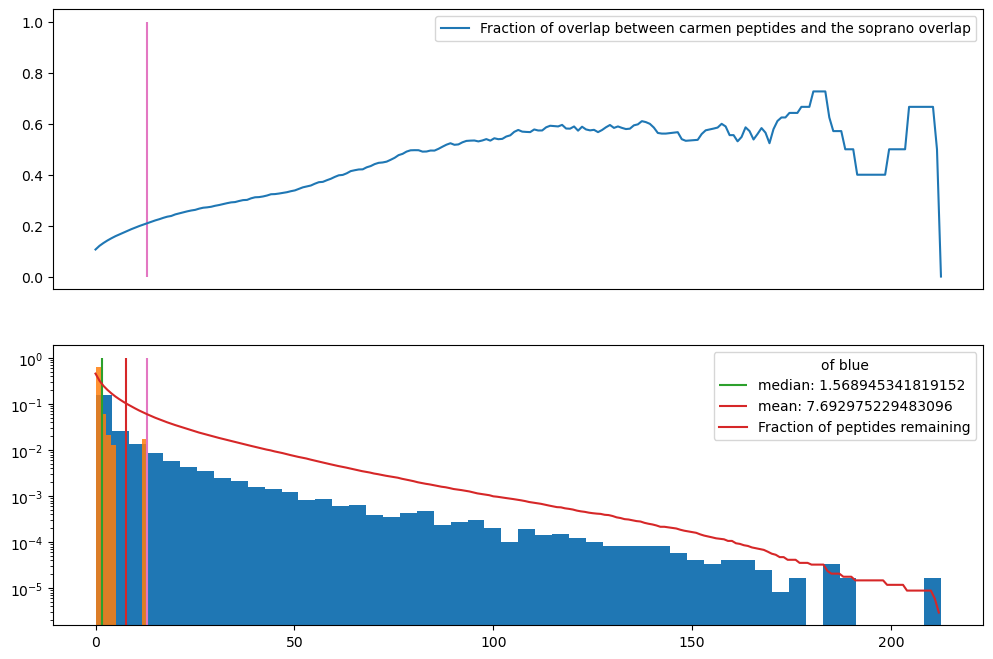

In [56]:
fig = plt.figure(figsize=(12,8))
ax1 = plt.subplot(211)
ax1.vlines(13,0,1,color="tab:pink")
ax1.plot(percent_overlap_9m, label="Fraction of overlap between carmen peptides and the soprano overlap")
ax1.legend()
ax1.set_xticklabels([])
ax1.set_xticks([])
ax = plt.subplot(212)
ax.hist(a0201carmensop_scores_9m["Promiscuity"], density=True, bins=50)
ax.vlines(a0201carmensop_scores_9m["Promiscuity"].median(), 0, 1, color="tab:green", label=f"median: {a0201carmensop_scores_9m['Promiscuity'].median()}")
ax.vlines(a0201carmensop_scores_9m["Promiscuity"].mean(), 0, 1, color="tab:red", label=f"mean: {a0201carmensop_scores_9m['Promiscuity'].mean()}")
ax.vlines(13,0,1,color="tab:pink")
ax.hist(a0201carmen_scores_9m["Promiscuity"], density=True, color="tab:orange", alpha=0.85)
ax.plot(percent_remaining_9m, color="tab:red", label="Fraction of peptides remaining")
ax.legend(title="of blue")
ax.set_yscale("log")
fig.savefig("Carmen_comparison_of_predicted_vs_detected_peptides_promiscuity_a0201_9mers_only.pdf")

In [30]:
soprano_a0201.join(bigscore, left_on="column_4", right_on="Contigs")["popcov_but_sqrt"].mean()

55.864558479350954

In [29]:
percent_overlap = []
for threshold in range(1,214):
    peptidesig = pep_main.filter(pl.col("Promiscuity")>threshold).select(pl.col("Peptide").unique()).select(pl.len()).collect().item()
    peptidesol = a0201_overlap_peptides.lazy().join(pep_main.filter(pl.col("Promiscuity")>threshold).select(pl.col("Peptide").unique()), right_on="Peptide", left_on="column_5").select(pl.len()).collect().item()
    percent_overlap.append(peptidesol/peptidesig)

In [67]:
a0201carmensop_scores

column_5,Study_id,Sample_name,Peptide_type,Spectral_count,Assigned_modifications,Haplotype,Netmhcpan_binder,Promiscuity
str,str,str,str,i64,str,str,str,f64
"""YATSKHAKI""","""PXD009531""","""sample_C1R-C0304""","""canonical""",2,null,"""C*03:04""","""Y""",0.0
"""TLPEENYQV""","""PXD023044""","""sample_F120190510_PF_MDA_MB231…","""canonical""",5,null,"""A*02:01,A*02:17,B*40:02,B*41:0…","""Y,Y,N,N,N,Y""",3.441342
"""EERQAHLTNQY""","""PXD003790""","""sample_U-87_DAC""","""canonical""",1,null,"""A*02:01:01,B*44:02,C*05:01:01""","""N,Y,N""",0.0
"""VYIHHFDRI""","""MSV000080527-84172-84442""","""sample_A2301""","""canonical""",3,null,"""A*23:01""","""Y""",33.899736
"""YITAAYVEM""","""PXD009531""","""sample_C1R-C0304""","""canonical""",4,null,"""C*03:04""","""Y""",0.0
…,…,…,…,…,…,…,…,…
"""DGLRLIAL""","""PXD004023""","""sample_JT2""","""canonical""",24,null,"""A*11:01,B*18:03,B*35:01""","""N,N,N""",0.0
"""KLLENMNKL""","""MSV000080527-84172-84442""","""sample_CLL_DFCI-5283""","""canonical""",4,null,"""A*02:06,A*24:02,B*08:01,B*51:0…","""Y,N,N,N,Y,N""",10.590457
"""YGVGAVASL""","""PXD014397""","""sample_PXD014397_F120190129_PF…","""canonical""",1,null,"""A*02:01,A*03:01,B*40:02,B*47,C…","""N,N,N,X,Y,Y""",0.932561


In [82]:
a0201carmen_scores.max()

pep_list,Study_id,Sample_name,Peptide_type,Spectral_count,Assigned_modifications,Haplotype,Netmhcpan_binder,Promiscuity
str,str,str,str,i64,str,str,str,f64
"""YYTPTISR""","""PXD034772""","""sample_SKMEL5_100nM""","""canonical""",18,"""N-term(42.0106)""",null,null,13.068715


In [62]:
soprano_a0201["column_4"].unique()

column_4
str
"""C67883"""
"""C178795"""
"""C101058"""
"""C230135"""
"""C159482"""
…
"""C186169"""
"""C72125"""
"""C82289"""


In [44]:
a0201_overlap_peptides

column_5
str
"""KELVEPVSRF"""
"""YLMEVTHDL"""
"""EFKLIPGLNNL"""
"""TYAKQYEEF"""
"""ILIATDVASRGL"""
…
"""ASFYQRALL"""
"""AVFDKCPEL"""
"""YVLGYKQTLK"""


In [22]:
pep_main.filter(pl.col("Sample_name")=="sample_Blank").collect()

Study_id,Sample_name,Peptide,Peptide_type,Spectral_count,Assigned_modifications,Haplotype,Netmhcpan_binder,Promiscuity
str,str,str,str,i64,str,str,str,f64
"""MSV000080527-84172-84442""","""sample_Blank""","""AAEDDEDDDVDTK""","""canonical""",1,null,null,null,10.270717
"""MSV000080527-84172-84442""","""sample_Blank""","""AAEDDEDDDVDTKK""","""canonical""",3,null,null,null,17.735407
"""MSV000080527-84172-84442""","""sample_Blank""","""ADDGRPFPQVIK""",null,1,null,null,null,0.459753
"""MSV000080527-84172-84442""","""sample_Blank""","""ADKEAAFDDAVEER""","""canonical""",1,"""N-term(42.0106)""",null,null,1.642249
"""MSV000080527-84172-84442""","""sample_Blank""","""ADLINNLGTIAK""","""canonical""",1,null,null,null,0.0
…,…,…,…,…,…,…,…,…
"""MSV000080527-84172-84442""","""sample_Blank""","""YHTINGHNAEVR""","""canonical""",1,null,null,null,0.428749
"""MSV000080527-84172-84442""","""sample_Blank""","""YIDQEELNK""","""canonical""",1,null,null,null,3.427796
"""MSV000080527-84172-84442""","""sample_Blank""","""YISPDQLADLYK""","""canonical""",1,null,null,null,3.992987


In [39]:
soprano_top70.join(contig_peptides, left_on="column_4", right_on="contig").with_columns(pl.col("pep_list").str.split(",").list.unique())

column_1,column_2,column_3,column_4,column_5,column_6,npep,pep_list,unique_peptides
str,i64,i64,str,list[str],str,u32,list[str],i64
"""chr1""",1050455,1050484,"""C100""","[""ARGPSGLLL"", ""LARGPSGLLL""]","""HLA-C0602,HLA-A1101,HLA-A6801,…",2,"[""ARGPSGLLL"", ""LARGPSGLLL""]",2
"""chr1""",77962833,77962925,"""C10000""","[""NADPNMKL"", ""IELQRNPPP"", … ""ETIKSISQQ""]","""HLA-A2402,HLA-A2601,HLA-B1501,…",8,"[""NADPNMKL"", ""IELQRNPPP"", … ""ISQQSGARI""]",8
"""chr7""",121351218,121351244,"""C100011""","[""IADLGSTSI""]","""HLA-A0201,HLA-B1801,HLA-B4402,…",1,"[""IADLGSTSI""]",1
"""chr7""",121362919,121362945,"""C100015""","[""KTGEVLDTK""]","""HLA-A1101,HLA-A0301,HLA-A2301,…",1,"[""KTGEVLDTK""]",1
"""chr7""",121378910,121378967,"""C100018""","[""ASLGNLFAR"", ""KMDASLGNLFA"", … ""KMDASLGNL""]","""HLA-A0101,HLA-A3201,HLA-B1302,…",10,"[""FEIKMDASLGNL"", ""DASLGNLFAR"", … ""YVISQVFEI""]",10
…,…,…,…,…,…,…,…,…
"""chr7""",120951175,120951235,"""C99966""","[""REMDLQVQN"", ""LPMDLRDRF"", … ""REMDLQVQNAMDQL""]","""HLA-B5301,HLA-A0101,HLA-A2301,…",5,"[""LPMDLRDRF"", ""REMDLQVQN"", … ""REMDLQVQNAM""]",5
"""chr7""",120969068,120969121,"""C99978""","[""SMARETVGY"", ""FQLGKEFSM"", ""NDFQLGKEF""]","""HLA-A0201,HLA-B1511,HLA-C0303,…",3,"[""NDFQLGKEF"", ""FQLGKEFSM"", ""SMARETVGY""]",3
"""chr7""",120970758,120970784,"""C99979""","[""SSSTVVQEI""]","""HLA-B1302,HLA-A0101,HLA-A3201,…",1,"[""SSSTVVQEI""]",1


In [33]:
soprano_top70["column_4"].unique()

column_4
str
"""C233080"""
"""C189370"""
"""C225475"""
"""C188063"""
"""C45266"""
…
"""C230235"""
"""C220500"""
"""C220552"""


In [31]:
soprano_top70.join(contig_peptides, left_on="column_4", right_on="contig").filter(pl.col("npep")!=pl.col("unique_peptides"))

column_1,column_2,column_3,column_4,column_5,column_6,npep,pep_list,unique_peptides
str,i64,i64,str,list[str],str,u32,str,i64
"""chr1""",77964254,77964356,"""C10003""","[""AVGIVIGRNGEMIKK"", ""IVIGRNGEM"", … ""EGIDVPIPR""]","""HLA-A1101,HLA-A1101,HLA-A1102,…",15,"""AVGIVIGRNGEMIKK,EGIDVPIPR,FAVG…",17
"""chr1""",77965195,77965231,"""C10009""","[""RLLDQIVEK"", ""TPESVQSAKRL"", … ""GLPERSCML""]","""HLA-A0201,HLA-A0217,HLA-B4002,…",6,"""GLPERSCML,GTPESVQSAK,IQIAPDSGG…",8
"""chr1""",77966884,77966917,"""C10009""","[""QESGCKIQI"", ""TPESVQSAKRL"", … ""MLTGTPESV""]","""HLA-A0201,HLA-A0217,HLA-B4002,…",6,"""GLPERSCML,GTPESVQSAK,IQIAPDSGG…",8
"""chr1""",78013071,78013175,"""C10015""","[""AFFGGSNPF"", ""FHGDPHATF"", … ""FGGSNPFEIF""]","""HLA-C1402,HLA-C1403,HLA-A3301,…",9,"""AFFGGSNPF,DPHATFAA,DPHATFAAF,F…",10
"""chr7""",123706749,123706826,"""C100163""","[""SPRGYFHTF"", ""FVYNSPRGY"", … ""KLLWEQELY""]","""HLA-A1101,HLA-A1102,HLA-B1502,…",6,"""DIKDGKLLW,FVYNSPRGY,KLLWEQELY,…",7
…,…,…,…,…,…,…,…,…
"""chr7""",117209880,117209937,"""C99883""","[""WEGTFRMI"", ""KRVEGALNL"", … ""KRVEGALNLL""]","""HLA-A0101,HLA-A2402,HLA-B1302,…",8,"""AHWKRVEGA,ALNLLHCTW,KRVEGALNL,…",9
"""chr7""",117219084,117219127,"""C99883""","[""PYPLEKGHLF"", ""KRVEGALNLL"", … ""WEGTFRMI""]","""HLA-A0101,HLA-A2402,HLA-B1302,…",8,"""AHWKRVEGA,ALNLLHCTW,KRVEGALNL,…",9
"""chr7""",117219084,117219127,"""C99883""","[""RMIPYPLEK"", ""PYPLEKGHLF"", … ""KRVEGALNL""]","""HLA-A0101,HLA-A2402,HLA-B1302,…",8,"""AHWKRVEGA,ALNLLHCTW,KRVEGALNL,…",9


In [35]:
soprano_other = pl.read_csv("../data/to-be-published/Common_IP_complete_topquartile.bed", separator="\t", has_header=False)

In [38]:
soprano_other

column_1,column_2,column_3,column_4,column_5,column_6,column_7,column_8,column_9,column_10,column_11,column_12
str,i64,i64,str,str,i64,i64,str,str,str,str,i64
"""chr1""",945112,945141,"""Peak_15226""","""chr1""",945112,945146,"""C15""","""EGFSERGILR,EGFSERGILR,EGFSERGI…","""sample_Mel-15_HLA-I,sample_QEh…","""HLA-A030101,HLA-A680101,HLA-B2…",29
"""chr1""",946194,946223,"""Peak_15225""","""chr1""",946173,946268,"""C16""","""DLNFPEIKR,DLNFPEIKR,DLNFPEIKR,…","""sample_A3301,sample_AML001_MHC…","""HLA-A3301,HLA-A32,HLA-A33,HLA-…",29
"""chr1""",948191,948232,"""Peak_15224""","""chr1""",948167,948232,"""C19""","""GLVEQLYDL,GLVEQLYDL,GLVEQLYDL,…","""sample_MEL_13240-015,sample_U-…","""HLA-A0201,HLA-A0202,HLA-B1302,…",41
"""chr1""",948529,948558,"""Peak_15223""","""chr1""",948499,948561,"""C20""","""KLSNVNLQEK,KLSNVNLQEK,KLSNVNLQ…","""sample_UWB1289-IFNg_HLA-Ip_BR2…","""HLA-A0301,HLA-A6801,HLA-B0702,…",29
"""chr1""",952439,952492,"""Peak_15221""","""chr1""",952439,952531,"""C25""","""AYQHAFLYI,AYQHAFLYI,AYQHAFLYI,…","""sample_A2402,sample_VY20210315…","""HLA-A2402,HLA-A2402,HLA-A2410,…",53
…,…,…,…,…,…,…,…,…,…,…,…
"""chrX""",155514129,155514158,"""Peak_16104""","""chrX""",155514129,155514164,"""C247857""","""AEIYQQAQV,YQQAQVPSV,YQQAQVPSV,…","""sample_bonemarrow_W6_005,sampl…","""HLA-A0101,HLA-A6901,HLA-B3701,…",29
"""chrY""",12841066,12841095,"""Peak_16872""","""chrY""",12841069,12841107,"""C248183""","""ARFLFTTGF,ARFLFTTGF,ARFLFTTGF,…","""sample_B2705,sample_C0702,samp…","""HLA-B2705,HLA-C0702,HLA-A0201,…",26
"""chrY""",12846443,12846472,"""Peak_16874""","""chrY""",12846434,12846475,"""C248189""","""AELGKLYSV,AELGKLYSV,AELGKLYSV,…","""sample_B4006,sample_B4501,samp…","""HLA-B4006,HLA-B4501,HLA-B4901,…",29


In [39]:
soprano_other

column_1,column_2,column_3,column_4,column_5,column_6,column_7,column_8,column_9,column_10,column_11,column_12
str,i64,i64,str,str,i64,i64,str,str,str,str,i64
"""chr1""",945112,945141,"""Peak_15226""","""chr1""",945112,945146,"""C15""","""EGFSERGILR,EGFSERGILR,EGFSERGI…","""sample_Mel-15_HLA-I,sample_QEh…","""HLA-A030101,HLA-A680101,HLA-B2…",29
"""chr1""",946194,946223,"""Peak_15225""","""chr1""",946173,946268,"""C16""","""DLNFPEIKR,DLNFPEIKR,DLNFPEIKR,…","""sample_A3301,sample_AML001_MHC…","""HLA-A3301,HLA-A32,HLA-A33,HLA-…",29
"""chr1""",948191,948232,"""Peak_15224""","""chr1""",948167,948232,"""C19""","""GLVEQLYDL,GLVEQLYDL,GLVEQLYDL,…","""sample_MEL_13240-015,sample_U-…","""HLA-A0201,HLA-A0202,HLA-B1302,…",41
"""chr1""",948529,948558,"""Peak_15223""","""chr1""",948499,948561,"""C20""","""KLSNVNLQEK,KLSNVNLQEK,KLSNVNLQ…","""sample_UWB1289-IFNg_HLA-Ip_BR2…","""HLA-A0301,HLA-A6801,HLA-B0702,…",29
"""chr1""",952439,952492,"""Peak_15221""","""chr1""",952439,952531,"""C25""","""AYQHAFLYI,AYQHAFLYI,AYQHAFLYI,…","""sample_A2402,sample_VY20210315…","""HLA-A2402,HLA-A2402,HLA-A2410,…",53
…,…,…,…,…,…,…,…,…,…,…,…
"""chrX""",155514129,155514158,"""Peak_16104""","""chrX""",155514129,155514164,"""C247857""","""AEIYQQAQV,YQQAQVPSV,YQQAQVPSV,…","""sample_bonemarrow_W6_005,sampl…","""HLA-A0101,HLA-A6901,HLA-B3701,…",29
"""chrY""",12841066,12841095,"""Peak_16872""","""chrY""",12841069,12841107,"""C248183""","""ARFLFTTGF,ARFLFTTGF,ARFLFTTGF,…","""sample_B2705,sample_C0702,samp…","""HLA-B2705,HLA-C0702,HLA-A0201,…",26
"""chrY""",12846443,12846472,"""Peak_16874""","""chrY""",12846434,12846475,"""C248189""","""AELGKLYSV,AELGKLYSV,AELGKLYSV,…","""sample_B4006,sample_B4501,samp…","""HLA-B4006,HLA-B4501,HLA-B4901,…",29


In [37]:
soprano_other.with_columns(pl.col("column_11").str.split(",").list.len())

column_1,column_2,column_3,column_4,column_5,column_6,column_7,column_8,column_9,column_10,column_11,column_12
str,i64,i64,str,str,i64,i64,str,str,str,u32,i64
"""chr1""",945112,945141,"""Peak_15226""","""chr1""",945112,945146,"""C15""","""EGFSERGILR,EGFSERGILR,EGFSERGI…","""sample_Mel-15_HLA-I,sample_QEh…",80,29
"""chr1""",946194,946223,"""Peak_15225""","""chr1""",946173,946268,"""C16""","""DLNFPEIKR,DLNFPEIKR,DLNFPEIKR,…","""sample_A3301,sample_AML001_MHC…",691,29
"""chr1""",948191,948232,"""Peak_15224""","""chr1""",948167,948232,"""C19""","""GLVEQLYDL,GLVEQLYDL,GLVEQLYDL,…","""sample_MEL_13240-015,sample_U-…",308,41
"""chr1""",948529,948558,"""Peak_15223""","""chr1""",948499,948561,"""C20""","""KLSNVNLQEK,KLSNVNLQEK,KLSNVNLQ…","""sample_UWB1289-IFNg_HLA-Ip_BR2…",395,29
"""chr1""",952439,952492,"""Peak_15221""","""chr1""",952439,952531,"""C25""","""AYQHAFLYI,AYQHAFLYI,AYQHAFLYI,…","""sample_A2402,sample_VY20210315…",391,53
…,…,…,…,…,…,…,…,…,…,…,…
"""chrX""",155514129,155514158,"""Peak_16104""","""chrX""",155514129,155514164,"""C247857""","""AEIYQQAQV,YQQAQVPSV,YQQAQVPSV,…","""sample_bonemarrow_W6_005,sampl…",56,29
"""chrY""",12841066,12841095,"""Peak_16872""","""chrY""",12841069,12841107,"""C248183""","""ARFLFTTGF,ARFLFTTGF,ARFLFTTGF,…","""sample_B2705,sample_C0702,samp…",446,26
"""chrY""",12846443,12846472,"""Peak_16874""","""chrY""",12846434,12846475,"""C248189""","""AELGKLYSV,AELGKLYSV,AELGKLYSV,…","""sample_B4006,sample_B4501,samp…",187,29


In [34]:
soprano_peptides

column_1,column_2,column_3,column_4,column_5
str,i64,i64,str,str
"""chr1""",945112,945146,"""C15""","""EGFSERGILR,EGFSERGILR,EGFSERGI…"
"""chr1""",946173,946268,"""C16""","""DLNFPEIKR,DLNFPEIKR,DLNFPEIKR,…"
"""chr1""",948167,948232,"""C19""","""GLVEQLYDL,GLVEQLYDL,GLVEQLYDL,…"
"""chr1""",948499,948561,"""C20""","""KLSNVNLQEK,KLSNVNLQEK,KLSNVNLQ…"
"""chr1""",951202,951234,"""C22""","""IPTARFYPL"""
…,…,…,…,…
"""chrY""",19720914,19720943,"""C248314""","""QPDLLHQL,QPDLLHQL,QPDLLHQL,QPD…"
"""chrY""",19721252,19721278,"""C248317""","""MPVLDQSVL,MPVLDQSVL"""
"""chrY""",19741801,19741857,"""C248326""","""DQIAKFWEI,DQIAKFWEI,DQIAKFWEI,…"


(array([6610., 4881., 3414., 2294., 1845., 1518., 1107.,  924.,  719.,
         620.,  528.,  429.,  355.,  304.,  320.,  230.,  229.,  260.,
         182.,  157.,  144.,  134.,  126.,  121.,   88.,  106.,   69.,
          90.,   69.,   57.,   52.,   66.,   64.,   48.,   26.,   45.,
          37.,   35.,   45.,   48.,   57.,   32.,   32.,   40.,   32.,
          12.,   34.,   36.,   22.,   24.]),
 array([   0.,   20.,   40.,   60.,   80.,  100.,  120.,  140.,  160.,
         180.,  200.,  220.,  240.,  260.,  280.,  300.,  320.,  340.,
         360.,  380.,  400.,  420.,  440.,  460.,  480.,  500.,  520.,
         540.,  560.,  580.,  600.,  620.,  640.,  660.,  680.,  700.,
         720.,  740.,  760.,  780.,  800.,  820.,  840.,  860.,  880.,
         900.,  920.,  940.,  960.,  980., 1000.]),
 <BarContainer object of 50 artists>)

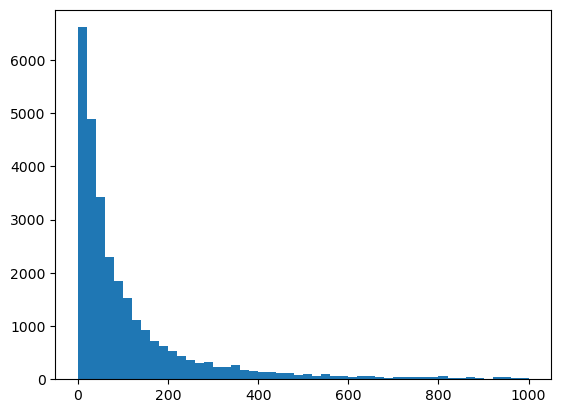

In [33]:
plt.hist(soprano_peptides.with_columns(pl.col("column_5").str.split(",").list.len())["column_5"], bins=50, range=[0,1000])

In [7]:
score = pl.scan_parquet(contig_hotspot_score_file)
score = score.with_columns(pl.col("Id").str.replace("S_0_", "C")).collect()

In [8]:
score_soprano = score.filter(pl.col("Id").is_in(soprano_peptides["column_4"]))

In [25]:
score.median()

unique_pep_idx,mut_count_idx,pop_cov_idx,Id,pop_cov,vlen,popcov_but_sqrt,unique_peptides,mutation_count,exon_length,normalized_unique_pep,ranking
f64,f64,f64,str,f64,f64,f64,f64,f64,f64,f64,f64
124262.5,124262.5,124262.5,null,0.569804,3.657775,1.321357,2.0,16.0,446.0,0.004193,381749.5


In [27]:
score_soprano.mean()

unique_pep_idx,mut_count_idx,pop_cov_idx,Id,pop_cov,vlen,popcov_but_sqrt,unique_peptides,mutation_count,exon_length,normalized_unique_pep,ranking
f64,f64,f64,str,f64,f64,f64,f64,f64,f64,f64,f64
87652.786151,103200.793854,48208.627574,null,15.438571,3.933086,29.502569,7.71652,86.68958,1328.161093,0.015725,239062.207579


In [14]:
score2 = pl.read_csv("contig_promiscuity_score_2_3_4.csv")
score2 = score2.with_columns(pl.col("Id").str.replace("S_0_", "C"))

In [16]:
score2_soprano = score2.filter(pl.col("Id").is_in(soprano_peptides["column_4"]))


In [18]:
score2_soprano.mean()

Id,popcov_but_sqrt2,popcov_but_sqrt3,popcov_but_sqrt4
str,f64,f64,f64
null,1.921757,0.345753,0.118357


In [17]:
score2.mean()

Id,popcov_but_sqrt2,popcov_but_sqrt3,popcov_but_sqrt4
str,f64,f64,f64
null,0.430008,0.07592,0.026104


In [54]:
score2_soprano.min()

Id,popcov_but_sqrt2,popcov_but_sqrt3,popcov_but_sqrt4
str,f64,f64,f64
"""C100018""",0.0,0.0,0.0


In [59]:
soprano_peptides

column_1,column_2,column_3,column_4,column_5
str,i64,i64,str,str
"""chr1""",945112,945146,"""C15""","""EGFSERGILR,EGFSERGILR,EGFSERGI…"
"""chr1""",946173,946268,"""C16""","""DLNFPEIKR,DLNFPEIKR,DLNFPEIKR,…"
"""chr1""",948167,948232,"""C19""","""GLVEQLYDL,GLVEQLYDL,GLVEQLYDL,…"
"""chr1""",948499,948561,"""C20""","""KLSNVNLQEK,KLSNVNLQEK,KLSNVNLQ…"
"""chr1""",951202,951234,"""C22""","""IPTARFYPL"""
…,…,…,…,…
"""chrY""",19720914,19720943,"""C248314""","""QPDLLHQL,QPDLLHQL,QPDLLHQL,QPD…"
"""chrY""",19721252,19721278,"""C248317""","""MPVLDQSVL,MPVLDQSVL"""
"""chrY""",19741801,19741857,"""C248326""","""DQIAKFWEI,DQIAKFWEI,DQIAKFWEI,…"


In [71]:
soprano_peptides = soprano_peptides.with_columns(pl.col("column_5").str.split(",").list.unique().alias("alia").list.len())

In [10]:
contig_peptides = pl.read_csv(contig_peptide_list_file, separator="\t")

In [81]:
test = pl.read_parquet("../data/subsidiary-files/hotspot_score_3_axis_per_contig.parquet")

In [82]:
test

Id,pop_cov,vlen,popcov_but_sqrt,unique_peptides,mutation_count
str,f64,f64,f64,u32,i64
"""S_0_149082""",0.298009,5.711207,0.772022,2,0
"""S_0_226521""",0.0,0.0,0.0,2,0
"""S_0_114348""",0.614968,7.130498,1.753523,1,0
"""S_0_101753""",0.259918,6.694733,0.720997,1,0
"""S_0_14125""",1.137863,2.515362,2.133413,1,0
…,…,…,…,…,…
"""S_0_99631""",6.299507,4.079763,14.198035,14,33767
"""S_0_192923""",6.071171,2.129545,10.740216,6,35682
"""S_0_192921""",28.550951,5.409594,72.282944,7,38228


In [79]:
score

unique_pep_idx,mut_count_idx,pop_cov_idx,Id,pop_cov,vlen,popcov_but_sqrt,unique_peptides,mutation_count,exon_length,normalized_unique_pep,ranking
u32,u32,u32,str,f64,f64,f64,u32,i64,i64,f64,u32
68,455,1,"""C204435""",1437.938488,0.754595,1904.709638,779,2028,3262,0.238811,524
73,718,2,"""C92394""",1437.341036,0.754629,1903.936473,778,1506,3477,0.223756,793
152,494,148,"""C150015""",216.698514,2.041091,377.894589,448,1936,3352,0.133652,794
229,344,261,"""C108617""",208.197362,0.887632,286.044687,89,2495,774,0.114987,834
74,822,5,"""C30878""",930.198787,1.116752,1353.351917,662,1378,2969,0.222971,901
…,…,…,…,…,…,…,…,…,…,…,…
247950,248089,240808,"""C98639""",0.0,0.0,0.0,1,0,14934,0.000067,736847
248049,248205,242709,"""C110884""",0.0,0.0,0.0,1,0,15974,0.000063,738963
243300,248500,248040,"""C50318""",0.0,0.0,0.0,1,0,6195,0.000161,739840


In [90]:
contig_peptides.filter(pl.col("contig")=="C243878")["pep_list"].to_list()

['HLGRPDGVPMPDKY,KSLLGKDVL,KSLLGKDVLF,LGKDVLFLK,LLGKDVLFL,MPDKYSLEPVAVELK,SHLGRPDGVPMPDKY,SLEPVAVEL,SLEPVAVELK,SLEPVAVELKS,SLLGKDVLFL,SLLGKDVLFLK,VELKSLLGKDVL,VELKSLLGKDVLF,YSLEPVAVEL,YSLEPVAVELK']

In [84]:
test.filter(pl.col("Id")=="S_0_243878")

Id,pop_cov,vlen,popcov_but_sqrt,unique_peptides,mutation_count
str,f64,f64,f64,u32,i64
"""S_0_243878""",0.0,0.0,0.0,1,4


In [78]:
contig_peptides.filter(pl.col("contig")=="C204435")

contig,pep_list,unique_peptides
str,str,i64
"""C204435""","""AASSSSLEK,AASSSSLEKS,AASSSSLEK…",779


In [72]:
soprano_peptides.join(score, right_on="Id", left_on="column_4").select(["unique_peptides","column_4","column_5","alia"])

unique_peptides,column_4,column_5,alia
u32,str,str,u32
779,"""C204435""","""AASSSSLEK,AASSSSLEK,AASSSSLEK,…",762
779,"""C204435""","""AASSSSLEK,AASSSSLEK,AASSSSLEK,…",762
779,"""C204435""","""AASSSSLEK,AASSSSLEK,AASSSSLEK,…",762
779,"""C204435""","""AASSSSLEK,AASSSSLEK,AASSSSLEK,…",762
779,"""C204435""","""AASSSSLEK,AASSSSLEK,AASSSSLEK,…",762
…,…,…,…
1,"""C248208""","""AVAARGLDI,AVAARGLDI,AVAARGLDI,…",19
1,"""C14483""","""SLGVHTYEL,SLGVHTYEL,SLGVHTYEL""",1
1,"""C243878""","""KSLLGKDVL,KSLLGKDVL,KSLLGKDVL,…",12


In [53]:
score_soprano.min()

unique_pep_idx,mut_count_idx,pop_cov_idx,Id,pop_cov,vlen,popcov_but_sqrt,unique_peptides,mutation_count,exon_length,normalized_unique_pep,ranking
u32,u32,u32,str,f64,f64,f64,u32,i64,i64,f64,u32
0,0,1,"""C100018""",0.0,0.0,0.0,1,0,29,0.00002,524


(array([1.99987929e-02, 4.82846865e-07, 8.04744775e-08, 4.02372388e-07,
        0.00000000e+00, 1.60948955e-07, 0.00000000e+00, 8.04744775e-08,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00]),
 array([   0.,   50.,  100.,  150.,  200.,  250.,  300.,  350.,  400.,
         450.,  500.,  

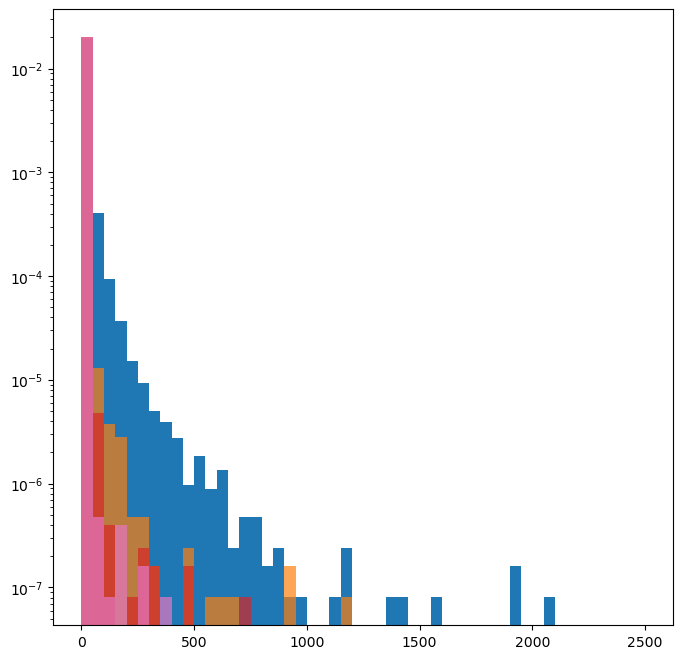

In [51]:
promthresh = plt.figure(figsize=(8,8))
ax = plt.subplot(111)
ax.set_yscale("log")
ax.hist(score["popcov_but_sqrt"], bins = 50, range =[0,2500], color="tab:blue", density=True)
ax.hist(score2["popcov_but_sqrt2"], bins = 50, range =[0,2500], color = "tab:orange", alpha = 0.7, density=True)
ax.hist(score2["popcov_but_sqrt3"], bins = 50, range =[0,2500], color = "tab:red", alpha = 0.7, density=True)
ax.hist(score2["popcov_but_sqrt4"], bins = 50, range =[0,2500], color = "tab:pink", alpha = 0.7, density=True)

(array([1.99930330e-02, 3.09645456e-06, 7.74113640e-07, 2.32234092e-06,
        0.00000000e+00, 7.74113640e-07, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00]),
 array([   0.,   50.,  100.,  150.,  200.,  250.,  300.,  350.,  400.,
         450.,  500.,  

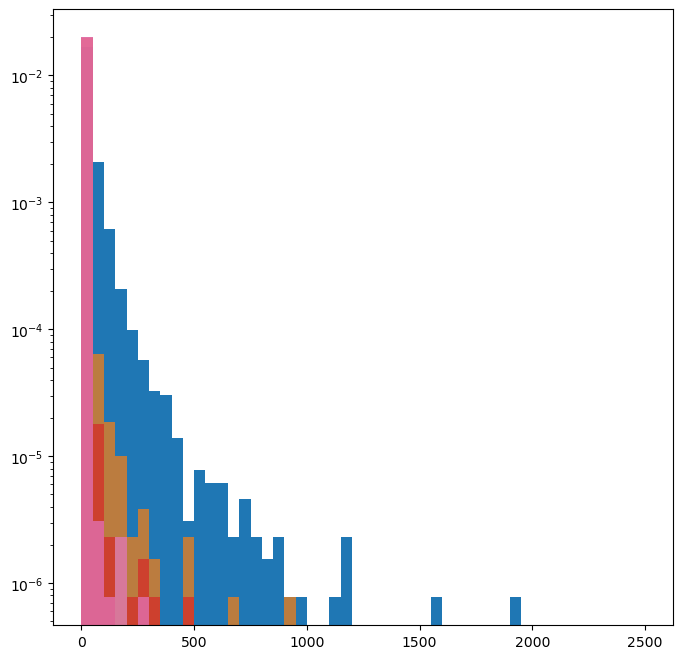

In [50]:
promthresh = plt.figure(figsize=(8,8))
ax = plt.subplot(111)
ax.set_yscale("log")
ax.hist(score_soprano["popcov_but_sqrt"], bins = 50, range =[0,2500], color="tab:blue", density=True)
ax.hist(score2_soprano["popcov_but_sqrt2"], bins = 50, range =[0,2500], color = "tab:orange", alpha = 0.7, density=True)
ax.hist(score2_soprano["popcov_but_sqrt3"], bins = 50, range =[0,2500], color = "tab:red", alpha = 0.7, density=True)
ax.hist(score2_soprano["popcov_but_sqrt4"], bins = 50, range =[0,2500], color = "tab:pink", alpha = 0.7, density=True)

(array([9.98026010e-02, 6.57996594e-05, 6.19290912e-05, 1.93528410e-05,
        1.54822728e-05, 1.16117046e-05, 0.00000000e+00, 0.00000000e+00,
        3.87056820e-06, 0.00000000e+00, 0.00000000e+00, 3.87056820e-06,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        3.87056820e-06, 0.00000000e+00, 0.00000000e+00, 7.74113640e-06,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 3.87056820e-06, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00]),
 array([  0.,  10.,  20.,  30.,  40.,  50.,  60.,  70.,  80.,  90., 100.,
        110., 120., 

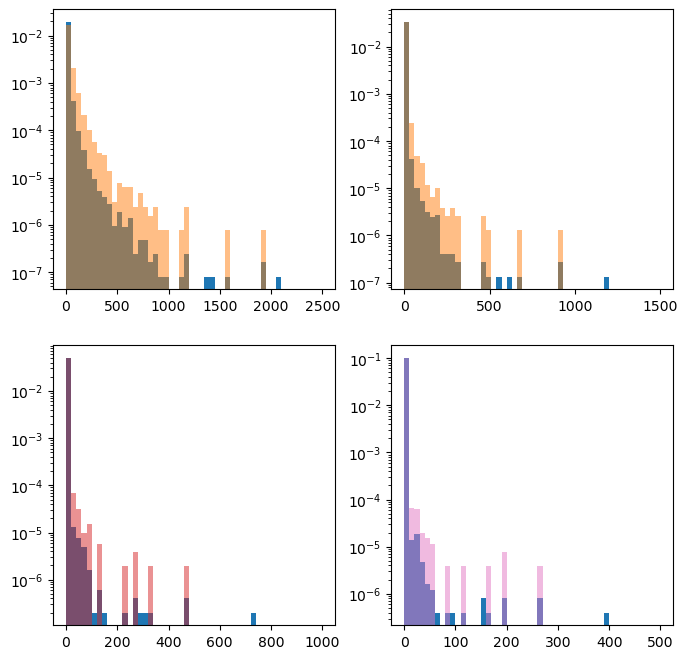

In [55]:
promthresh2 = plt.figure(figsize=(8,8))
ax1 = plt.subplot(221)
ax1.set_yscale("log")
ax1.hist(score["popcov_but_sqrt"], bins = 50, range =[0,2500], color="tab:blue", density=True)
ax1.hist(score_soprano["popcov_but_sqrt"], bins = 50, range =[0,2500], color="tab:orange", alpha = 0.5, density=True)
ax2 = plt.subplot(222)
ax2.set_yscale("log")
ax2.hist(score2["popcov_but_sqrt2"], bins = 50, range =[0,1500], color = "tab:blue", density=True)
ax2.hist(score2_soprano["popcov_but_sqrt2"], bins = 50, range =[0,1500], color = "tab:orange", alpha = 0.5, density=True)
ax3 = plt.subplot(223)
ax3.set_yscale("log")
ax3.hist(score2["popcov_but_sqrt3"], bins = 50, range =[0,1000], color = "tab:blue", density=True)
ax3.hist(score2_soprano["popcov_but_sqrt3"], bins = 50, range =[0,1000], color = "tab:red", alpha = 0.5, density=True)
ax4 = plt.subplot(224)
ax4.set_yscale("log")
ax4.hist(score2["popcov_but_sqrt4"], bins = 50, range =[0,500], color = "tab:blue", density=True)
ax4.hist(score2_soprano["popcov_but_sqrt4"], bins = 50, range =[0,500], color = "tab:pink", alpha = 0.5, density=True)

In [6]:
emilia_umap_with_ids.filter(pl.col("Sample")=="sample_CELG")["Binding_alleles"][0]

'A*02:01,A*24:02,B*15:01,B*73:01,C*03:03'

# Generating the promiscuity for carmen peptide clusters list

In [5]:
contig_peptide_list = pl.read_csv(
contig_peptide_list_file, 
separator='\t'
)

In [7]:
znow_bijatyka = pl.read_parquet(db_main_file)

In [11]:
znow_bijatyka.filter(pl.col("Sample_name")=="sample_CELG")

Study_id,Sample_name,Peptide,Peptide_type,Spectral_count,Assigned_modifications,Haplotype,Netmhcpan_binder,Promiscuity
str,str,str,str,i64,str,str,str,f64
"""PXD004023""","""sample_CELG""","""AAAAAAAGSPY""","""canonical""",1,null,"""A*02:01,A*24:02,B*15:01,B*73:0…","""N,N,Y,N,N""",0.537603
"""PXD004023""","""sample_CELG""","""AAAAAAQSVY""","""canonical""",6,null,"""A*02:01,A*24:02,B*15:01,B*73:0…","""N,N,Y,N,N""",22.710888
"""PXD004023""","""sample_CELG""","""AAAAAQSVY""","""canonical""",10,null,"""A*02:01,A*24:02,B*15:01,B*73:0…","""N,N,Y,N,Y""",35.268721
"""PXD004023""","""sample_CELG""","""AAAFAGLSREEALR""","""canonical""",1,null,"""A*02:01,A*24:02,B*15:01,B*73:0…","""N,N,N,N,N""",0.465729
"""PXD004023""","""sample_CELG""","""AAAGRSPHL""","""canonical""",1,null,"""A*02:01,A*24:02,B*15:01,B*73:0…","""N,N,N,N,Y""",7.564345
…,…,…,…,…,…,…,…,…
"""PXD004023""","""sample_CELG""","""YYSPHGHILVL""","""canonical""",47,null,"""A*02:01,A*24:02,B*15:01,B*73:0…","""N,Y,N,N,N""",46.938864
"""PXD004023""","""sample_CELG""","""YYTEFTPTEKDE""",null,1,null,"""A*02:01,A*24:02,B*15:01,B*73:0…","""N,N,N,N,N""",4.848416
"""PXD004023""","""sample_CELG""","""YYTPITPHL""","""canonical""",14,null,"""A*02:01,A*24:02,B*15:01,B*73:0…","""Y,Y,N,N,Y""",99.760046


In [12]:
unique_peptide_in_carmen_list = znow_bijatyka.unique("Peptide").select("Peptide")

In [13]:
emilia_umap_with_ids

index,Sample,Binding_alleles,x,y,label,Id,Peptides
u32,str,str,f64,f64,i64,str,list[str]
0,"""sample_PXD027182_NB8_PASEGA_0B…","""A*02:01,A*24:02,B*51:01:01,B*5…",0.191533,2.5076637,3,"""GC_0""","[""AAMPRPVSY"", ""AAYGRSPMV"", … ""YAAPHPLQSY""]"
1,"""sample_PXD027182_NB8_PASEGA_0B…","""A*02:01,A*24:02,B*51:01:01,B*5…",-1.854416,9.617391,13,"""GC_1""","[""AYASQFGTF"", ""AYGSLFNTI"", … ""YYTPITPHL""]"
2,"""sample_PXD027182_NB8_PASEGA_0B…","""A*02:01,A*24:02,B*51:01:01,B*5…",5.087642,6.512341,6,"""GC_2""","[""ALPPVLTTV"", ""DPPPGSHVI"", … ""YPVEQMTTI""]"
3,"""sample_PXD027182_NB8_PASEGA_0B…","""A*02:01,A*24:02,B*51:01:01,B*5…",-1.499036,1.5007926,10,"""GC_3""","[""AIVDKVPSV"", ""ALADGVQKV"", … ""YQVGQLYSV""]"
4,"""sample_PXD027182_NB8_PASEGA_0B…","""A*02:01,A*24:02,B*51:01:01,B*5…",4.7801905,5.940344,6,"""GC_4""","[""DAAAKALRI"", ""DAAEFAISI"", … ""YAFPKAVSV""]"
…,…,…,…,…,…,…,…
5688,"""sample_20200513_COL015_00007a_…",null,5.4869995,1.7892371,0,"""GC_5688""","[""AEEYEFLTPVEEAPK"", ""ALQHMTDFAIQFNK"", … ""YGPSSVSFADDFVR""]"
5689,"""sample_20200513_COL015_00007a_…",null,5.382379,2.0899956,0,"""GC_5689""","[""AAAFEEQENETVVVK"", ""AALSASEGEEVPQDK"", … ""YVAEIEKEKEENEKK""]"
5690,"""sample_20200513_COL015_00007a_…",null,5.620569,3.7104275,0,"""GC_5690""","[""AGVNVEPFWPGLFAK"", ""AYSNWPTYPQLYVK"", … ""YNEQHVPGSPFTAR""]"


In [14]:
xallcen = (emilia_umap_with_ids["x"].min() + emilia_umap_with_ids["x"].max() )/2
yallcen = (emilia_umap_with_ids["y"].min() + emilia_umap_with_ids["y"].max() )/2

In [19]:
xallcen

1.2168582499999996

In [52]:
def promiscuity_single_peptide(input):
    scorebase = emilia_umap_with_ids.with_columns(hit = pl.col("Peptides").list.contains(input))
    xy = scorebase.filter(pl.col("hit")==True).select("x","y")
    count = len(xy)
    if count == 0 :
        return 0
    xcen = xy["x"].sum()/count
    ycen = xy["y"].sum()/count
    lth = np.sqrt( np.power(xallcen-xcen,2) + np.power(yallcen-ycen,2))
    popcov_but_sqrt = count / math.sqrt(1+lth)
    return popcov_but_sqrt

In [77]:
emilia_umap_with_ids

index,Sample,Binding_alleles,x,y,label,Id,Peptides
u32,str,str,f64,f64,i64,str,list[str]
0,"""sample_PXD027182_NB8_PASEGA_0B…","""A*02:01,A*24:02,B*51:01:01,B*5…",0.191533,2.5076637,3,"""GC_0""","[""AAMPRPVSY"", ""AAYGRSPMV"", … ""YAAPHPLQSY""]"
1,"""sample_PXD027182_NB8_PASEGA_0B…","""A*02:01,A*24:02,B*51:01:01,B*5…",-1.854416,9.617391,13,"""GC_1""","[""AYASQFGTF"", ""AYGSLFNTI"", … ""YYTPITPHL""]"
2,"""sample_PXD027182_NB8_PASEGA_0B…","""A*02:01,A*24:02,B*51:01:01,B*5…",5.087642,6.512341,6,"""GC_2""","[""ALPPVLTTV"", ""DPPPGSHVI"", … ""YPVEQMTTI""]"
3,"""sample_PXD027182_NB8_PASEGA_0B…","""A*02:01,A*24:02,B*51:01:01,B*5…",-1.499036,1.5007926,10,"""GC_3""","[""AIVDKVPSV"", ""ALADGVQKV"", … ""YQVGQLYSV""]"
4,"""sample_PXD027182_NB8_PASEGA_0B…","""A*02:01,A*24:02,B*51:01:01,B*5…",4.7801905,5.940344,6,"""GC_4""","[""DAAAKALRI"", ""DAAEFAISI"", … ""YAFPKAVSV""]"
…,…,…,…,…,…,…,…
5688,"""sample_20200513_COL015_00007a_…",null,5.4869995,1.7892371,0,"""GC_5688""","[""AEEYEFLTPVEEAPK"", ""ALQHMTDFAIQFNK"", … ""YGPSSVSFADDFVR""]"
5689,"""sample_20200513_COL015_00007a_…",null,5.382379,2.0899956,0,"""GC_5689""","[""AAAFEEQENETVVVK"", ""AALSASEGEEVPQDK"", … ""YVAEIEKEKEENEKK""]"
5690,"""sample_20200513_COL015_00007a_…",null,5.620569,3.7104275,0,"""GC_5690""","[""AGVNVEPFWPGLFAK"", ""AYSNWPTYPQLYVK"", … ""YNEQHVPGSPFTAR""]"


In [ ]:
miota_nim_jak_szatan = pl.read_parquet("/data/teamgdansk/carmen-peptide-clusters-characteristics.parquet")

In [79]:
miota_nim_jak_szatan = miota_nim_jak_szatan.with_columns(pl.col("Peptides").str.split(";"))

In [81]:
miota_nim_jak_szatan

ID,Sample_name,Peptides,Binding_alleles,UMAP_x,UMAP_y,Label,Freq_AAFA_A,Freq_AFB_A,Freq_AINDI_A,Freq_AISC_A,Freq_ALANAM_A,Freq_AMIND_A,Freq_CARB_A,Freq_CARHIS_A,Freq_CARIBI_A,Freq_EURCAU_A,Freq_FILII_A,Freq_HAWI_A,Freq_JAPI_A,Freq_KORI_A,Freq_MENAFC_A,Freq_MSWHIS_A,Freq_NCHI_A,Freq_SCAHIS_A,Freq_SCAMB_A,Freq_SCSEAI_A,Freq_VIET_A,Freq_AAFA_B,Freq_AFB_B,Freq_AINDI_B,Freq_AISC_B,Freq_ALANAM_B,Freq_AMIND_B,Freq_CARB_B,Freq_CARHIS_B,Freq_CARIBI_B,…,Freq_AMIND_ABC_any,Freq_CARB_ABC_any,Freq_CARHIS_ABC_any,Freq_CARIBI_ABC_any,Freq_EURCAU_ABC_any,Freq_FILII_ABC_any,Freq_HAWI_ABC_any,Freq_JAPI_ABC_any,Freq_KORI_ABC_any,Freq_MENAFC_ABC_any,Freq_MSWHIS_ABC_any,Freq_NCHI_ABC_any,Freq_SCAHIS_ABC_any,Freq_SCAMB_ABC_any,Freq_SCSEAI_ABC_any,Freq_VIET_ABC_any,Freq_AAFA_ABC_all,Freq_AFB_ABC_all,Freq_AINDI_ABC_all,Freq_AISC_ABC_all,Freq_ALANAM_ABC_all,Freq_AMIND_ABC_all,Freq_CARB_ABC_all,Freq_CARHIS_ABC_all,Freq_CARIBI_ABC_all,Freq_EURCAU_ABC_all,Freq_FILII_ABC_all,Freq_HAWI_ABC_all,Freq_JAPI_ABC_all,Freq_KORI_ABC_all,Freq_MENAFC_ABC_all,Freq_MSWHIS_ABC_all,Freq_NCHI_ABC_all,Freq_SCAHIS_ABC_all,Freq_SCAMB_ABC_all,Freq_SCSEAI_ABC_all,Freq_VIET_ABC_all
str,str,list[str],str,f64,f64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""P_1""","""sample_05H143""","[""AAAELAAQK"", ""AAALPAAALW"", … ""YTNPCTKSW""]","""A*02:01;A*34:02;B*08:01;B*57:0…",-3.154053,7.0074296,2,0.156997,0.145948,0.049222,0.268294,0.194414,0.279521,0.146324,0.176801,0.154138,0.276425,0.068218,0.120805,0.147994,0.185754,0.198492,0.225582,0.094646,0.214107,0.165513,0.057917,0.03497,0.044721,0.037756,0.104219,0.108505,0.087936,0.109063,0.035275,0.056685,0.054778,…,0.432989,0.319588,0.362861,0.351568,0.484377,0.103205,0.189181,0.162613,0.273946,0.412167,0.352757,0.150721,0.352402,0.344302,0.274646,0.112,0.004382,0.003414,0.001291,0.015343,0.01329,0.014858,0.003175,0.009396,0.007191,0.021055,0.000945,0.004881,0.000887,0.000531,0.009793,0.007345,0.00022,0.006683,0.004706,0.00094,0.000232
"""P_2""","""sample_05H143""","[""AAAKPTPPK"", ""AIYEPKTFK"", … ""YVSVPGSKK""]","""A*02:01;A*34:02;B*08:01;B*57:0…",4.243943,-0.07093,1,0.156997,0.145948,0.049222,0.268294,0.194414,0.279521,0.146324,0.176801,0.154138,0.276425,0.068218,0.120805,0.147994,0.185754,0.198492,0.225582,0.094646,0.214107,0.165513,0.057917,0.03497,0.044721,0.037756,0.104219,0.108505,0.087936,0.109063,0.035275,0.056685,0.054778,…,0.432989,0.319588,0.362861,0.351568,0.484377,0.103205,0.189181,0.162613,0.273946,0.412167,0.352757,0.150721,0.352402,0.344302,0.274646,0.112,0.004382,0.003414,0.001291,0.015343,0.01329,0.014858,0.003175,0.009396,0.007191,0.021055,0.000945,0.004881,0.000887,0.000531,0.009793,0.007345,0.00022,0.006683,0.004706,0.00094,0.000232
"""P_3""","""sample_05H143""","[""AAFPAEKESEW"", ""AIKQLDYEW"", … ""YVTDVLYRV""]","""A*02:01;A*34:02;B*08:01;B*57:0…",-1.851911,0.8354455,4,0.156997,0.145948,0.049222,0.268294,0.194414,0.279521,0.146324,0.176801,0.154138,0.276425,0.068218,0.120805,0.147994,0.185754,0.198492,0.225582,0.094646,0.214107,0.165513,0.057917,0.03497,0.044721,0.037756,0.104219,0.108505,0.087936,0.109063,0.035275,0.056685,0.054778,…,0.432989,0.319588,0.362861,0.351568,0.484377,0.103205,0.189181,0.162613,0.273946,0.412167,0.352757,0.150721,0.352402,0.344302,0.274646,0.112,0.004382,0.003414,0.001291,0.015343,0.01329,0.014858,0.003175,0.009396,0.007191,0.021055,0.000945,0.004881,0.000887,0.000531,0.009793,0.007345,0.00022,0.006683,0.004706,0.00094,0.000232
"""P_4""","""sample_05H143_1""","[""AAAKPTPPK"", ""APATPLVNK"", … ""YVSVPGSKK""]","""A*02:01;A*34:02;B*08:01;B*57:0…",4.2816453,-0.099384,1,0.156997,0.145948,0.049222,0.268294,0.194414,0.279521,0.146324,0.176801,0.154138,0.276425,0.068218,0.120805,0.147994,0.185754,0.198492,0.225582,0.094646,0.214107,0.165513,0.057917,0.03497,0.044721,

In [74]:
def promiscuity_peptide_list(input):
    scorebase = emilia_umap_with_ids\
        .with_columns(
        scafres = pl.col("Peptides").list.set_intersection(input
        ))\
        .with_columns(alen = pl.col("scafres").list.len()).sort("alen")
    xy = scorebase.filter(pl.col("alen")>0).select("x","y")
    count = len(xy)
    if count == 0 :
        return 0
    xcen = xy["x"].sum()/count
    ycen = xy["y"].sum()/count
    lth = np.sqrt( np.power(xallcen-xcen,2) + np.power(yallcen-ycen,2))
    popcov_but_sqrt = count / math.sqrt(1+lth)
    return popcov_but_sqrt

In [87]:
popcov_but_sqrt = []
for motif in miota_nim_jak_szatan.iter_rows(named=True):
    popcov_but_sqrt.append(promiscuity_peptide_list(motif["Peptides"]))

In [ ]:
miota_nim_jak_szatan2 = pl.read_parquet("/data/teamgdansk/carmen-peptide-clusters-characteristics.parquet")

In [92]:
miota_nim_jak_szatan2.hstack(pl.DataFrame({"Promiscuity":popcov_but_sqrt})).write_parquet("/data/teamgdansk/carmen-peptide-clusters-characteristics_with_promiscuity.parquet")

In [24]:
emilia_umap_with_ids.with_columns(npep = pl.col("Peptides").list.len()).filter(pl.col("npep")>0)


index,Sample,Binding_alleles,x,y,label,Id,Peptides,npep
u32,str,str,f64,f64,i64,str,list[str],u32
0,"""sample_PXD027182_NB8_PASEGA_0B…","""A*02:01,A*24:02,B*51:01:01,B*5…",0.191533,2.5076637,3,"""GC_0""","[""AAMPRPVSY"", ""AAYGRSPMV"", … ""YAAPHPLQSY""]",20
1,"""sample_PXD027182_NB8_PASEGA_0B…","""A*02:01,A*24:02,B*51:01:01,B*5…",-1.854416,9.617391,13,"""GC_1""","[""AYASQFGTF"", ""AYGSLFNTI"", … ""YYTPITPHL""]",242
2,"""sample_PXD027182_NB8_PASEGA_0B…","""A*02:01,A*24:02,B*51:01:01,B*5…",5.087642,6.512341,6,"""GC_2""","[""ALPPVLTTV"", ""DPPPGSHVI"", … ""YPVEQMTTI""]",106
3,"""sample_PXD027182_NB8_PASEGA_0B…","""A*02:01,A*24:02,B*51:01:01,B*5…",-1.499036,1.5007926,10,"""GC_3""","[""AIVDKVPSV"", ""ALADGVQKV"", … ""YQVGQLYSV""]",225
4,"""sample_PXD027182_NB8_PASEGA_0B…","""A*02:01,A*24:02,B*51:01:01,B*5…",4.7801905,5.940344,6,"""GC_4""","[""DAAAKALRI"", ""DAAEFAISI"", … ""YAFPKAVSV""]",158
…,…,…,…,…,…,…,…,…
5688,"""sample_20200513_COL015_00007a_…",null,5.4869995,1.7892371,0,"""GC_5688""","[""AEEYEFLTPVEEAPK"", ""ALQHMTDFAIQFNK"", … ""YGPSSVSFADDFVR""]",62
5689,"""sample_20200513_COL015_00007a_…",null,5.382379,2.0899956,0,"""GC_5689""","[""AAAFEEQENETVVVK"", ""AALSASEGEEVPQDK"", … ""YVAEIEKEKEENEKK""]",213
5690,"""sample_20200513_COL015_00007a_…",null,5.620569,3.7104275,0,"""GC_5690""","[""AGVNVEPFWPGLFAK"", ""AYSNWPTYPQLYVK"", … ""YNEQHVPGSPFTAR""]",27


(array([117., 133.,  76.,  60.,  54.,  43.,  36.,  40.,  46.,  37.]),
 array([ 0.,  5., 10., 15., 20., 25., 30., 35., 40., 45., 50.]),
 <BarContainer object of 10 artists>)

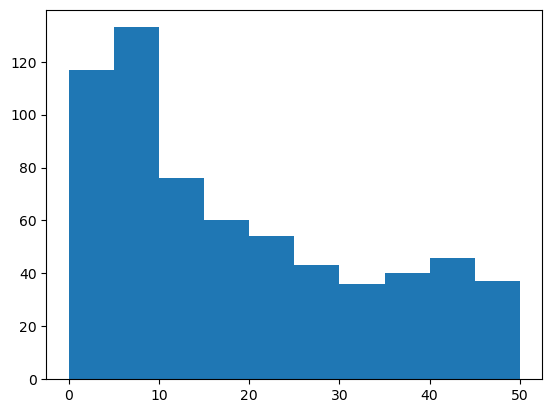

In [16]:
plt.hist(emilia_umap_with_ids.with_columns(npep = pl.col("Peptides").list.len())["npep"], range=[0,50])

In [25]:
emilia_umap_with_ids.explode("Peptides")["Peptides"].value_counts().sort("count").tail(10)

Peptides,count
str,u32
"""KLIPQLPTL""",394
"""ALATLIHQV""",396
"""FLSELTQQL""",399
"""ALMPVLNQV""",399
"""RLPEAIEEV""",404
"""KIYEGQVEV""",424
"""QLVDIIEKV""",426
"""ILMEHIHKL""",457
"""ALADGVQKV""",460


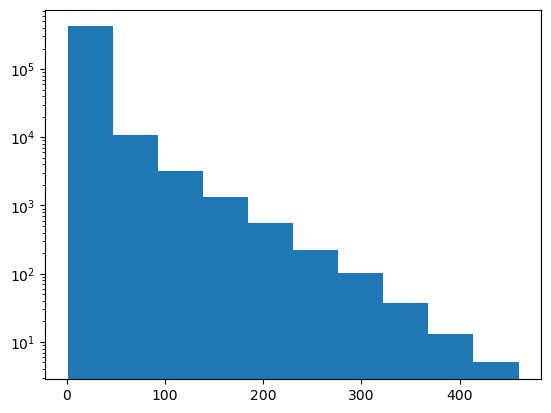

In [7]:
plt.hist(emilia_umap_with_ids.explode("Peptides")["Peptides"].value_counts()["count"])
plt.yscale("log")

# Final Cleanup

This is to clean up and delete all additional files and directories created throughout the analysis.

**Do not run the second cell unless you want to end your work here or start over.**

In [ ]:
# This is a safety code

raise KeyboardInterrupt("Are you sure you want to run the cell below?")

In [ ]:
# Run this cell to do a clean-up

temp_dir.joinpath(f"trashpanda{i}.parquet").unlink(missing_ok=True)

shutil.rmtree(data_subs_dir)
shutil.rmtree(figures_gen_dir)
shutil.rmtree(temp_dir)

In [ ]:
print("\n".join([f"{f}" for f in ext_data_files]))